# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 그대로 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 감성 분류 미세 조정

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.

이건 1번째 코드 셀이에요


In [32]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")

Repo: C:\Users\cedis\PycharmProjects\gpt-lab


이건 2번째 코드 셀이에요


In [2]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.

이건 3번째 코드 셀이에요


In [3]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

이미 존재합니다: C:\Users\cedis\PycharmProjects\gpt-lab\data\ratings_train.txt
이미 존재합니다: C:\Users\cedis\PycharmProjects\gpt-lab\data\ratings_test.txt
사전 학습 train 텍스트: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_val.txt (120,560자)
감성 분류 train: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_train.txt
LM val exists: True C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_val.txt


이건 4번째 코드 셀이에요


In [35]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.

이건 5번째 코드 셀이에요


In [36]:
run_pytest("tests/test_bpe.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_bpe.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.02s ==============================


선택한 테스트를

0

이건 6번째 코드 셀이에요


In [6]:
# BPE 구현 후 작은 말뭉치로 인코딩/디코딩 복원을 확인합니다.
try:
    from bpe import BPETokenizer

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    sample = "이 영화는 정말 좋았다! English 123"
    ids = tokenizer.encode(sample, add_bos_eos=True)
    print(ids[:20])
    print(tokenizer.decode(ids))
except NotImplementedError as e:
    print("BPE TODO 미구현:", e)

[2, 265, 260, 290, 268, 260, 164, 153, 274, 148, 260, 166, 143, 281, 156, 270, 37, 36, 73, 114]
이 영화는 정말 좋았다! English 123


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.

이건 7번째 코드 셀이에요


In [7]:
run_pytest("tests/test_dataset.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_dataset.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 4 items

tests/test_dataset.py::TestGPTDataset::test_dataset_length PASSED        [ 25%]
tests/test_dataset.py::TestGPTDataset::test_dataset_getitem_shape PASSED [ 50%]
tests/test_dataset.py::TestCreateDataloader::test_dataloader_batch_shape PASSED [ 75%]
tests/test_dataset.py::TestInputEmbedding::test_input_embedding_shape PASSED [100%]

============================== 4 passed in 2.31s ==============================


선택한 테스트를 통과했습니다.


0

이건 8번째 코드 셀이에요


In [8]:
try:
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=300, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)

torch.Size([2, 32]) torch.Size([2, 32]) torch.Size([2, 32, 32])


## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.

이건 9번째 코드 셀이에요


In [9]:
run_pytest("tests/test_attention.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_attention.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 2 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [ 50%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [100%]

============================== 2 passed in 1.41s ==============================


선택한 테스트를 통과했습니다.


0

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.

이건 10번째 코드 셀이에요


In [10]:
run_pytest("tests/test_model.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_model.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 7 items

tests/test_model.py::TestLayerNorm::test_layernorm_shape PASSED          [ 14%]
tests/test_model.py::TestGELU::test_gelu_shape PASSED                    [ 28%]
tests/test_model.py::TestFeedForward::test_feedforward_shape PASSED      [ 42%]
tests/test_model.py::TestTransformerBlock::test_transformer_block_shape PASSED [ 57%]
tests/test_model.py::TestGPTModel::test_gpt_forward_shape PASSED         [ 71%]
tests/test_model.py::TestGPTModel::test_gpt_forward_with_targets_returns_loss PASSED [ 85%]
tests/test_model.py::TestGenerateTextSimple::test_generate_text_simple_shape PASSED [

0

이건 11번째 코드 셀이에요


In [11]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NotImplementedError as e:
    print("Model TODO 미구현:", e)

torch.Size([2, 16, 300])


## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.

이건 12번째 코드 셀이에요


In [12]:
run_pytest("tests/test_train.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_train.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 5 items

tests/test_train.py::TestCalcLossBatch::test_calc_loss_batch_returns_scalar PASSED [ 20%]
tests/test_train.py::TestCalcLossLoader::test_calc_loss_loader_returns_float PASSED [ 40%]
tests/test_train.py::TestCheckpoint::test_save_load_checkpoint_restores_epoch_and_step PASSED [ 60%]
tests/test_train.py::TestGenerate::test_generate_shape PASSED            [ 80%]
tests/test_train.py::TestPlotLosses::test_plot_losses_callable PASSED    [100%]

============================== 5 passed in 2.55s ==============================


선택한 테스트를 통과했습니다.


0

이건 13번째 코드 셀이에요


In [13]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()
    print("smoke loss:", loss.item())
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)

smoke loss: 5.9834418296813965


## 8. Step 6 - 감성 분류 미세 조정

구현 파일: `src/finetune.py`

NSMC JSONL/TSV를 읽어 분류 Dataset을 만들고, GPT backbone 위에 classification head를 붙입니다.

이건 14번째 코드 셀이에요


In [14]:
run_pytest("tests/test_finetune.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_finetune.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 4 items

tests/test_finetune.py::TestMakeSentimentDataset::test_make_sentiment_dataset_splits_rows PASSED [ 25%]
tests/test_finetune.py::TestReviewSentimentDataset::test_review_sentiment_dataset_getitem PASSED [ 50%]
tests/test_finetune.py::TestGPTForSequenceClassification::test_sequence_classification_shape PASSED [ 75%]
tests/test_finetune.py::TestSentimentTrainEval::test_train_eval_functions_exist PASSED [100%]

============================== 4 passed in 1.35s ==============================


선택한 테스트를 통과했습니다.


0

## 9. 전체 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 전체 테스트를 실행합니다.

이건 15번째 코드 셀이에요


In [15]:
run_pytest("tests/")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/ -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 28 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [  3%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [  7%]
tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 10%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 14%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 17%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 21%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 25%]


0

이건 16번째 코드 셀이에요


In [16]:
from pathlib import Path

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

corpus = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:10000]

tokenizer = BPETokenizer(vocab_size=500)
tokenizer.train(corpus)

ids = tokenizer.encode(corpus, add_bos_eos=False)
print("num tokens:", len(ids))

context_length = 32

train_loader = create_dataloader(
    ids,
    context_length=context_length,
    batch_size=4,
    shuffle=True,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 64,
    "n_heads": 4,
    "n_layers": 1,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=None,
    optimizer=optimizer,
    device=device,
    num_epochs=1,
    eval_freq=0,
    eval_iter=0,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=None,
)

print("train_losses:", train_losses)

start_ids = tokenizer.encode("영화가", add_bos_eos=False)
idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

out = generate(
    model=model,
    idx=idx,
    max_new_tokens=20,
    context_size=context_length,
    temperature=1.0,
    top_k=20,
    eos_id=tokenizer.get_eos_id(),
)

print(tokenizer.decode(out[0].tolist(), skip_special=True))

device: cuda
num tokens: 11376
train_losses: [6.2522271938538285]
영화가 내���ㅋㅋ�����전하�는�마� ��이� 좋


이건 17번째 코드 셀이에요


In [19]:
from pathlib import Path

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

corpus = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:100000]
val_corpus = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")[:20000]

tokenizer = BPETokenizer(vocab_size=1000)
tokenizer.train(corpus)

train_ids = tokenizer.encode(corpus, add_bos_eos=False)
val_ids = tokenizer.encode(val_corpus, add_bos_eos=False)

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))

context_length = 64
batch_size = 16

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=100,
    eval_freq=100,
    eval_iter=5,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=None,
)

print("train_losses:", train_losses)

for start_text in ["영화가", "정말", "배우가"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=40,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(tokenizer.decode(out[0].tolist(), skip_special=True))

device: cuda
train tokens: 82148
val tokens: 16555
Step 100: train loss 6.2649, val loss 6.2792
Step 200: train loss 6.2145, val loss 6.2525
Step 300: train loss 6.1528, val loss 6.1610
Step 400: train loss 5.8752, val loss 5.9625
Step 500: train loss 5.7339, val loss 5.6941
Step 600: train loss 5.4179, val loss 5.4478
Step 700: train loss 5.2072, val loss 5.2734
Step 800: train loss 5.0583, val loss 5.1497
Step 900: train loss 4.8483, val loss 5.0589
Step 1000: train loss 4.7275, val loss 4.9940
Step 1100: train loss 4.7012, val loss 4.9414
Step 1200: train loss 4.6153, val loss 4.9032
Step 1300: train loss 4.5542, val loss 4.8721
Step 1400: train loss 4.4212, val loss 4.8539
Step 1500: train loss 4.3934, val loss 4.8381
Step 1600: train loss 4.3313, val loss 4.8267
Step 1700: train loss 4.4057, val loss 4.8199
Step 1800: train loss 4.1684, val loss 4.8224
Step 1900: train loss 4.1137, val loss 4.8214
Step 2000: train loss 4.1658, val loss 4.8182
Step 2100: train loss 4.0271, val loss

이건 18번째 코드 셀이에요


In [20]:
from pathlib import Path
import time

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate, calc_loss_loader, save_checkpoint


start_time = time.perf_counter()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

VOCAB_SIZE = 2000
TOKENIZER_PATH = Path(f"data/vocab_basic_{VOCAB_SIZE}.json")

tokenizer = BPETokenizer(vocab_size=VOCAB_SIZE)

if TOKENIZER_PATH.exists():
    print("load tokenizer:", TOKENIZER_PATH)
    tokenizer.load(TOKENIZER_PATH)
else:
    print("train tokenizer")
    tokenizer.train(train_text)
    tokenizer.save(TOKENIZER_PATH)
    print("saved tokenizer:", TOKENIZER_PATH)

print("encode train")
train_ids = tokenizer.encode(train_text, add_bos_eos=False)

print("encode val")
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=3,
    eval_freq=200,
    eval_iter=20,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=500,
)

final_val_loss = calc_loss_loader(
    val_loader,
    model,
    device,
    num_batches=50,
)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=3,
    global_step=len(train_loader) * 3,
    path="checkpoints/basic_full_final.pt",
)

print("train_losses:", train_losses)
print("final_val_loss:", final_val_loss)

for start_text in ["영화가", "정말", "배우가", "스토리는"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=80,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(tokenizer.decode(out[0].tolist(), skip_special=True))

elapsed = time.perf_counter() - start_time
print(f"elapsed: {elapsed:.1f}s")

device: cuda
train tokenizer
saved tokenizer: data\vocab_basic_2000.json
encode train
encode val
train tokens: 900849
val tokens: 78686
train batches: 220
val batches: 20
Step 200: train loss 6.9251, val loss 6.9280
Step 400: train loss 6.7773, val loss 6.7830
Step 600: train loss 6.3854, val loss 6.3138
train_losses: [7.061828784509139, 6.865258726206693, 6.495676428621466]
final_val_loss: 6.168029737472534
prompt: 영화가
영화가다
재밌�
평점으로 뽡에 비해자이 많이지의 �을 그 필요하는거리지
별 영화라한다. 오래서 tv요... 진짜의 진아..
고...
별의 나에.. 이름 영화도가 그�기심이렇게 가라스가 참다
그랭는 어�주이 지
prompt: 정말
정말 개판 말으로영화로 지나
성고 사람해도 안벽 C�로 이쁘해라에 잘 0점에 나이들도 그다. 아. 왜?. 뭐어가 아니다. 드라마가, 재밌었다. of
난 진짜 그이가 아깝다
전의 거지 글라전히 무다. 왜
전인은 그렇게
prompt: 배우가
배우가? 더빙이 더욱한 사랑과 대�를 주는 너무 하리고고 감동하게 너무 다에 정말 하면서의 너무것서는 하나을 이쁘어한 드라마도 더 너무 이 영화를 그거.. 말아다고 가기서 재밌는 이름이 참다
평점이가 좋는데 ""이 가치들도 나의 �00자이는 것
prompt: 스토리는
스토리는 한
별도 이거려도 너무게 보고 어게 해도 못고 하치하는 좋었다
제로 어쩠이 지한 것은 ""한 영화는 안
재밌다보는데 생각이네요아라가 되이 더도 나가 아니라가 남가만... 다 재밌도 좋다. 그저 Foo믹도 안되이 더의
elapsed: 1097.9s


이건 19번째 코드 셀이에요


In [21]:
from pathlib import Path
import time

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate, calc_loss_loader, save_checkpoint, load_checkpoint


start_time = time.perf_counter()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

start_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_full_final.pt",
    device=device,
)

print("resume epoch:", start_epoch)
print("resume global_step:", global_step)
print("train batches:", len(train_loader))

EXTRA_EPOCHS = 30

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=EXTRA_EPOCHS,
    eval_freq=500,
    eval_iter=20,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=1000,
    start_epoch=start_epoch,
    global_step=global_step,
)

final_global_step = global_step + len(train_loader) * EXTRA_EPOCHS
final_epoch = start_epoch + EXTRA_EPOCHS

final_val_loss = calc_loss_loader(
    val_loader,
    model,
    device,
    num_batches=50,
)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=final_epoch,
    global_step=final_global_step,
    path=f"checkpoints/basic_full_epoch_{final_epoch}.pt",
)

print("continued train_losses:", train_losses)
print("final_val_loss:", final_val_loss)

for start_text in ["영화가", "정말", "배우가", "스토리는", "이 영화는"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=120,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(tokenizer.decode(out[0].tolist(), skip_special=True))

elapsed = time.perf_counter() - start_time
print(f"elapsed: {elapsed:.1f}s")
print("final_epoch:", final_epoch)
print("final_global_step:", final_global_step)

device: cuda
resume epoch: 3
resume global_step: 660
train batches: 220
Step 1000: train loss 5.7360, val loss 5.6755
Step 1500: train loss 5.4070, val loss 5.3922
Step 2000: train loss 5.2982, val loss 5.2652
Step 2500: train loss 5.1551, val loss 5.1914
Step 3000: train loss 5.0985, val loss 5.1439
Step 3500: train loss 5.0338, val loss 5.1082
Step 4000: train loss 4.9966, val loss 5.0851
Step 4500: train loss 4.9219, val loss 5.0650
Step 5000: train loss 4.9460, val loss 5.0485
Step 5500: train loss 4.9011, val loss 5.0300
Step 6000: train loss 4.8224, val loss 5.0250
Step 6500: train loss 4.8688, val loss 5.0127
Step 7000: train loss 4.8406, val loss 5.0020
continued train_losses: [6.049400539831682, 5.770001073317094, 5.593169383569197, 5.473657209222967, 5.3854138374328615, 5.31684298732064, 5.261382644826716, 5.216652198271318, 5.178371897610751, 5.145807667212053, 5.118046894940463, 5.091538808562539, 5.068849463896318, 5.048790368166837, 5.0304039673371745, 5.01317580613223, 4

이건 20번째 코드 셀이에요


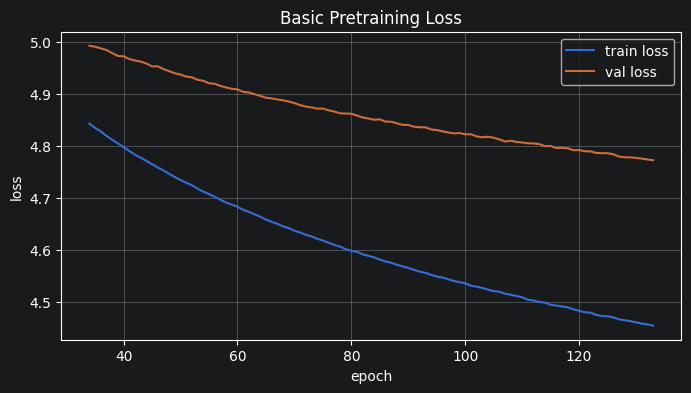

latest epoch: 133
global_step: 29260
train_loss: 4.4536618947982785
val_loss: 4.772017192840576
elapsed: 286.1 sec


In [22]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader, save_checkpoint, load_checkpoint


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

start_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_full_epoch_33.pt",
    device=device,
)

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
}

EPOCHS_TO_RUN = 100
EVAL_BATCHES = 20
start_time = time.perf_counter()

for epoch in range(start_epoch, start_epoch + EPOCHS_TO_RUN):
    model.train()
    epoch_losses = []

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        global_step += 1

    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=EVAL_BATCHES)

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=epoch + 1,
        global_step=global_step,
        path=f"checkpoints/basic_monitor_latest.pt",
    )

    clear_output(wait=True)

    plt.figure(figsize=(8, 4))
    plt.plot(history["epoch"], history["train_loss"], label="train loss")
    plt.plot(history["epoch"], history["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Basic Pretraining Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("latest epoch:", epoch + 1)
    print("global_step:", global_step)
    print("train_loss:", train_loss)
    print("val_loss:", val_loss)
    print("elapsed:", round(time.perf_counter() - start_time, 1), "sec")

    Path("checkpoints/basic_monitor_history.json").write_text(
        json.dumps(history, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

이건 21번째 코드 셀이에요


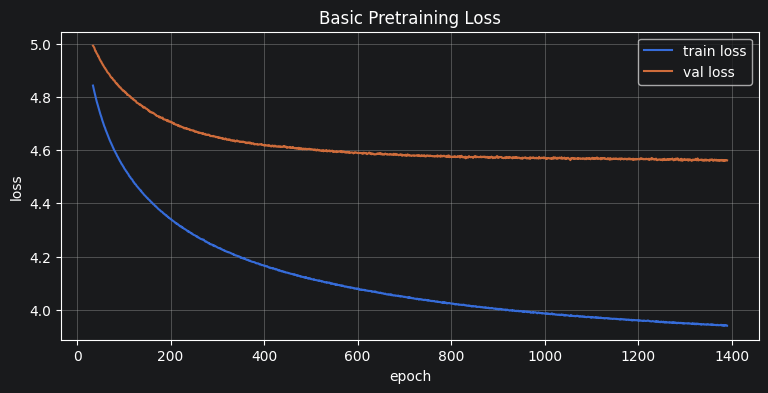

latest epoch: 1390
global_step: 305800
train_loss: 3.940032276240262
val_loss: 4.561598777770996
best_val_loss: 4.559159135818481
elapsed: 3595.8 sec
remaining: 4.2 sec
done
final epoch: 1392
global_step: 306240
best_val_loss: 4.558745741844177
elapsed: 3601.5 sec


In [23]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader, save_checkpoint, load_checkpoint


MAX_SECONDS = 60 * 60
EVAL_BATCHES = 20
PLOT_EVERY = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

current_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_monitor_latest.pt",
    device=device,
)

history_path = Path("checkpoints/basic_monitor_history.json")
history = json.loads(history_path.read_text(encoding="utf-8"))

best_val_loss = min(history["val_loss"])
print("start epoch:", current_epoch)
print("start global_step:", global_step)
print("best val loss:", best_val_loss)

start_time = time.perf_counter()

while time.perf_counter() - start_time < MAX_SECONDS:
    model.train()
    epoch_losses = []

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        global_step += 1

    current_epoch += 1

    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=EVAL_BATCHES)

    history["epoch"].append(current_epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=current_epoch,
        global_step=global_step,
        path="checkpoints/basic_monitor_latest.pt",
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=current_epoch,
            global_step=global_step,
            path="checkpoints/basic_monitor_best.pt",
        )

    history_path.write_text(
        json.dumps(history, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    if current_epoch % PLOT_EVERY == 0:
        clear_output(wait=True)

        plt.figure(figsize=(9, 4))
        plt.plot(history["epoch"], history["train_loss"], label="train loss")
        plt.plot(history["epoch"], history["val_loss"], label="val loss")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title("Basic Pretraining Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

        elapsed = time.perf_counter() - start_time
        print("latest epoch:", current_epoch)
        print("global_step:", global_step)
        print("train_loss:", train_loss)
        print("val_loss:", val_loss)
        print("best_val_loss:", best_val_loss)
        print("elapsed:", round(elapsed, 1), "sec")
        print("remaining:", round(MAX_SECONDS - elapsed, 1), "sec")

elapsed = time.perf_counter() - start_time

print("done")
print("final epoch:", current_epoch)
print("global_step:", global_step)
print("best_val_loss:", best_val_loss)
print("elapsed:", round(elapsed, 1), "sec")

이건 22번째 코드 셀이에요


device: cuda
activation: gelu
gelu epoch 001 train 7.0567 val 6.9261
gelu epoch 002 train 6.8747 val 6.7288
gelu epoch 003 train 6.5265 val 6.2022
gelu epoch 004 train 6.0647 val 5.8091
gelu epoch 005 train 5.7782 val 5.5992
gelu epoch 006 train 5.5978 val 5.4645
gelu epoch 007 train 5.4746 val 5.3749
gelu epoch 008 train 5.3839 val 5.3117
gelu epoch 009 train 5.3145 val 5.2606
gelu epoch 010 train 5.2589 val 5.2248
gelu epoch 011 train 5.2139 val 5.1945
gelu epoch 012 train 5.1761 val 5.1734
gelu epoch 013 train 5.1438 val 5.1498
gelu epoch 014 train 5.1156 val 5.1345
gelu epoch 015 train 5.0899 val 5.1187
gelu epoch 016 train 5.0678 val 5.1051
gelu epoch 017 train 5.0471 val 5.0949
gelu epoch 018 train 5.0296 val 5.0833
gelu epoch 019 train 5.0114 val 5.0742
gelu epoch 020 train 4.9958 val 5.0699
gelu epoch 021 train 4.9815 val 5.0599
gelu epoch 022 train 4.9672 val 5.0541
gelu epoch 023 train 4.9539 val 5.0488
gelu epoch 024 train 4.9410 val 5.0445
gelu epoch 025 train 4.9298 val 5.

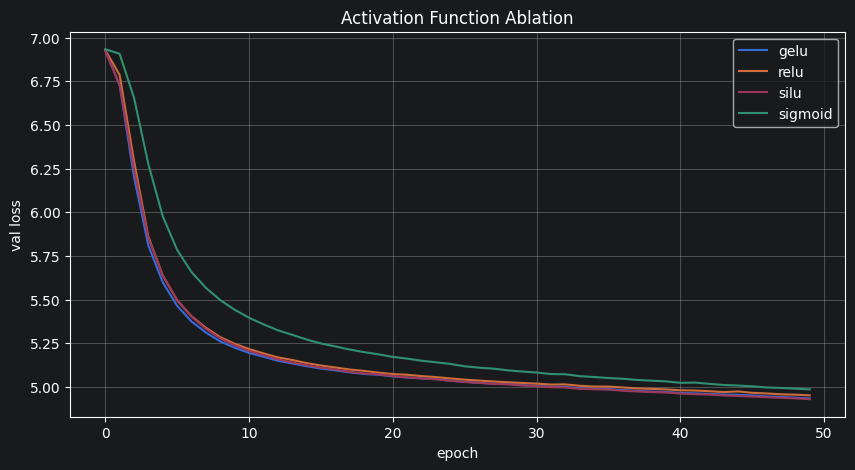

gelu final val loss: 4.9344 best val loss: 4.9344 elapsed: 126.1
relu final val loss: 4.952 best val loss: 4.952 elapsed: 125.1
silu final val loss: 4.9297 best val loss: 4.9297 elapsed: 125.8
sigmoid final val loss: 4.9861 best val loss: 4.9861 elapsed: 119.8


In [1]:
from pathlib import Path
import time
import json

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32
epochs = 50
eval_batches = 20
seed = 123

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

def make_activation(name):
    if name == "gelu":
        return nn.GELU()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)

def replace_activation(model, name):
    for block in model.blocks:
        block.ffn.net[1] = make_activation(name)

def make_loader(token_ids, shuffle, seed):
    dataset = GPTDataset(token_ids, context_length)
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
    )

results = {}

for activation_name in ["gelu", "relu", "silu", "sigmoid"]:
    print("=" * 50)
    print("activation:", activation_name)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_loader = make_loader(train_ids, shuffle=True, seed=seed)
    val_loader = make_loader(val_ids, shuffle=False, seed=seed)

    model = GPTModel(config).to(device)
    replace_activation(model, activation_name)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

    train_losses = []
    val_losses = []

    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = sum(epoch_losses) / len(epoch_losses)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_batches)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"{activation_name} epoch {epoch:03d} "
            f"train {train_loss:.4f} val {val_loss:.4f}"
        )

    elapsed = time.perf_counter() - start

    results[activation_name] = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "elapsed": elapsed,
    }

    print("elapsed:", round(elapsed, 1), "sec")

Path("checkpoints/activation_ablation_results.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

plt.figure(figsize=(10, 5))
for name, result in results.items():
    plt.plot(result["val_loss"], label=name)

plt.xlabel("epoch")
plt.ylabel("val loss")
plt.title("Activation Function Ablation")
plt.legend()
plt.grid(True)
plt.show()

for name, result in results.items():
    print(
        name,
        "final val loss:",
        round(result["val_loss"][-1], 4),
        "best val loss:",
        round(min(result["val_loss"]), 4),
        "elapsed:",
        round(result["elapsed"], 1),
    )

이건 23번째 코드 셀이에요


In [2]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel, FeedForward, GELU
from src.train import calc_loss_batch, calc_loss_loader


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

TRAIN_TEXT = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
VAL_TEXT = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

TOKENIZER_CACHE = {}
IDS_CACHE = {}

BASE_CONFIG = {
    "vocab_size": 2000,
    "context_length": 128,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

def get_tokenizer(vocab_size):
    if vocab_size in TOKENIZER_CACHE:
        return TOKENIZER_CACHE[vocab_size]

    path = Path(f"data/vocab_ablation_{vocab_size}.json")
    tokenizer = BPETokenizer(vocab_size=vocab_size)

    if path.exists():
        tokenizer.load(path)
    else:
        tokenizer.train(TRAIN_TEXT)
        tokenizer.save(path)

    TOKENIZER_CACHE[vocab_size] = tokenizer
    return tokenizer

def get_ids(vocab_size):
    if vocab_size in IDS_CACHE:
        return IDS_CACHE[vocab_size]

    tokenizer = get_tokenizer(vocab_size)
    train_ids = tokenizer.encode(TRAIN_TEXT, add_bos_eos=False)
    val_ids = tokenizer.encode(VAL_TEXT, add_bos_eos=False)
    IDS_CACHE[vocab_size] = (train_ids, val_ids)
    return train_ids, val_ids

def make_activation(name):
    if name == "gelu":
        return GELU()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)

def apply_overrides(model, config, overrides):
    activation = overrides.get("activation", "gelu")
    ffn_mult = overrides.get("ffn_mult", 4)

    for block in model.blocks:
        block.ffn = FeedForward(
            config["emb_dim"],
            dropout=config["drop_rate"],
            mult=ffn_mult,
        ).to(DEVICE)
        block.ffn.net[1] = make_activation(activation)

def make_loader(token_ids, context_length, batch_size, shuffle, seed):
    dataset = GPTDataset(token_ids, context_length)
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
    )

def make_optimizer(model, overrides):
    lr = overrides.get("learning_rate", 3e-4)
    weight_decay = overrides.get("weight_decay", 0.0)
    opt_name = overrides.get("optimizer", "adamw")

    if opt_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if opt_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if opt_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    raise ValueError(opt_name)

def run_one_experiment(name, overrides, epochs=30, seed=123, eval_batches=20):
    config = dict(BASE_CONFIG)
    config.update({k: v for k, v in overrides.items() if k in config})

    vocab_size = config["vocab_size"]
    context_length = config["context_length"]
    batch_size = overrides.get("batch_size", 32)

    train_ids, val_ids = get_ids(vocab_size)

    train_loader = make_loader(train_ids, context_length, batch_size, True, seed)
    val_loader = make_loader(val_ids, context_length, batch_size, False, seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = GPTModel(config).to(DEVICE)
    apply_overrides(model, config, overrides)
    optimizer = make_optimizer(model, overrides)

    train_losses = []
    val_losses = []
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
            loss.backward()

            if overrides.get("grad_clip") is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), overrides["grad_clip"])

            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = sum(epoch_losses) / len(epoch_losses)
        val_loss = calc_loss_loader(val_loader, model, DEVICE, num_batches=eval_batches)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"{name} epoch {epoch:03d} train {train_loss:.4f} val {val_loss:.4f}")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "elapsed": time.perf_counter() - start,
        "overrides": overrides,
    }

def run_ablation(category, variants, epochs=30):
    results = {}

    for name, overrides in variants:
        print("=" * 60)
        print(category, name)
        results[name] = run_one_experiment(
            name=f"{category}/{name}",
            overrides=overrides,
            epochs=epochs,
        )

    Path(f"checkpoints/ablation_{category}.json").write_text(
        json.dumps(results, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    plt.figure(figsize=(10, 5))
    for name, result in results.items():
        plt.plot(result["val_loss"], label=name)

    plt.xlabel("epoch")
    plt.ylabel("val loss")
    plt.title(f"{category} ablation")
    plt.legend()
    plt.grid(True)
    plt.show()

    for name, result in results.items():
        print(
            name,
            "final val:",
            round(result["val_loss"][-1], 4),
            "best val:",
            round(min(result["val_loss"]), 4),
            "elapsed:",
            round(result["elapsed"], 1),
        )

    return results

device: cuda


이건 24번째 코드 셀이에요


activation gelu
activation/gelu epoch 001 train 7.0561 val 6.9256
activation/gelu epoch 002 train 6.8731 val 6.7230
activation/gelu epoch 003 train 6.5174 val 6.1885
activation/gelu epoch 004 train 6.0586 val 5.8060
activation/gelu epoch 005 train 5.7780 val 5.5978
activation/gelu epoch 006 train 5.5989 val 5.4648
activation/gelu epoch 007 train 5.4760 val 5.3771
activation/gelu epoch 008 train 5.3857 val 5.3141
activation/gelu epoch 009 train 5.3168 val 5.2646
activation/gelu epoch 010 train 5.2615 val 5.2299
activation/gelu epoch 011 train 5.2155 val 5.1994
activation/gelu epoch 012 train 5.1785 val 5.1781
activation/gelu epoch 013 train 5.1459 val 5.1540
activation/gelu epoch 014 train 5.1170 val 5.1383
activation/gelu epoch 015 train 5.0919 val 5.1222
activation/gelu epoch 016 train 5.0686 val 5.1103
activation/gelu epoch 017 train 5.0488 val 5.0998
activation/gelu epoch 018 train 5.0306 val 5.0870
activation/gelu epoch 019 train 5.0122 val 5.0772
activation/gelu epoch 020 train 4.

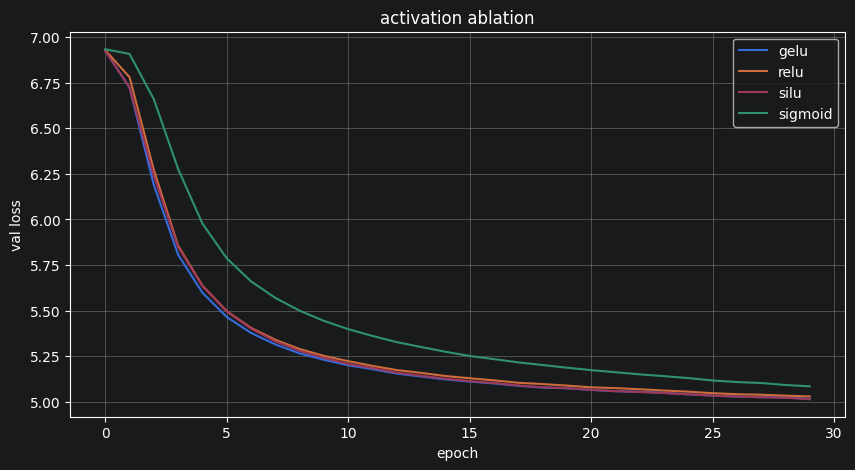

gelu final val: 5.0153 best val: 5.0153 elapsed: 73.6
relu final val: 5.0288 best val: 5.0288 elapsed: 66.8
silu final val: 5.0134 best val: 5.0134 elapsed: 63.9
sigmoid final val: 5.0842 best val: 5.0842 elapsed: 70.1


In [37]:
activation_results = run_ablation(
    "activation",
    [
        ("gelu", {"activation": "gelu"}),
        ("relu", {"activation": "relu"}),
        ("silu", {"activation": "silu"}),
        ("sigmoid", {"activation": "sigmoid"}),
    ],
    epochs=30,
)

이건 25번째 코드 셀이에요


dropout drop_0_0
dropout/drop_0_0 epoch 001 train 7.0448 val 6.9227
dropout/drop_0_0 epoch 002 train 6.8168 val 6.6119
dropout/drop_0_0 epoch 003 train 6.2761 val 5.9947
dropout/drop_0_0 epoch 004 train 5.7838 val 5.6724
dropout/drop_0_0 epoch 005 train 5.5181 val 5.4911
dropout/drop_0_0 epoch 006 train 5.3492 val 5.3745
dropout/drop_0_0 epoch 007 train 5.2328 val 5.3004
dropout/drop_0_0 epoch 008 train 5.1468 val 5.2493
dropout/drop_0_0 epoch 009 train 5.0802 val 5.2114
dropout/drop_0_0 epoch 010 train 5.0256 val 5.1828
dropout/drop_0_0 epoch 011 train 4.9793 val 5.1619
dropout/drop_0_0 epoch 012 train 4.9395 val 5.1485
dropout/drop_0_0 epoch 013 train 4.9036 val 5.1339
dropout/drop_0_0 epoch 014 train 4.8711 val 5.1263
dropout/drop_0_0 epoch 015 train 4.8417 val 5.1184
dropout/drop_0_0 epoch 016 train 4.8141 val 5.1163
dropout/drop_0_0 epoch 017 train 4.7879 val 5.1130
dropout/drop_0_0 epoch 018 train 4.7635 val 5.1130
dropout/drop_0_0 epoch 019 train 4.7409 val 5.1094
dropout/drop_0

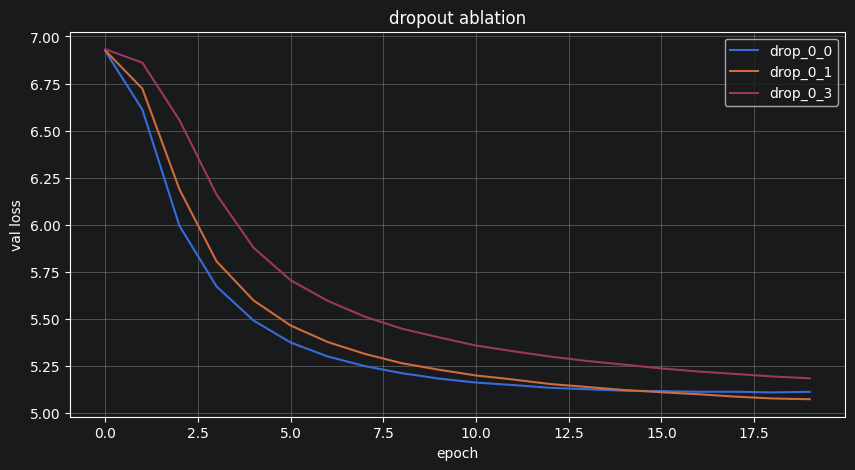

drop_0_0 final val: 5.1127 best val: 5.1094 elapsed: 51.1
drop_0_1 final val: 5.0733 best val: 5.0733 elapsed: 58.4
drop_0_3 final val: 5.1842 best val: 5.1842 elapsed: 47.8


In [38]:
# ABLATION_DROPOUT
dropout_results = run_ablation(
    "dropout",
    [
        ("drop_0_0", {"drop_rate": 0.0}),
        ("drop_0_1", {"drop_rate": 0.1}),
        ("drop_0_3", {"drop_rate": 0.3}),
    ],
    epochs=20,
)


이건 26번째 코드 셀이에요


learning_rate lr_1e_4
learning_rate/lr_1e_4 epoch 001 train 7.2475 val 6.9452
learning_rate/lr_1e_4 epoch 002 train 6.9418 val 6.9307
learning_rate/lr_1e_4 epoch 003 train 6.9315 val 6.9209
learning_rate/lr_1e_4 epoch 004 train 6.9140 val 6.8904
learning_rate/lr_1e_4 epoch 005 train 6.8604 val 6.7993
learning_rate/lr_1e_4 epoch 006 train 6.7532 val 6.6589
learning_rate/lr_1e_4 epoch 007 train 6.6117 val 6.4895
learning_rate/lr_1e_4 epoch 008 train 6.4511 val 6.3075
learning_rate/lr_1e_4 epoch 009 train 6.2904 val 6.1421
learning_rate/lr_1e_4 epoch 010 train 6.1480 val 6.0056
learning_rate/lr_1e_4 epoch 011 train 6.0317 val 5.9002
learning_rate/lr_1e_4 epoch 012 train 5.9351 val 5.8139
learning_rate/lr_1e_4 epoch 013 train 5.8531 val 5.7377
learning_rate/lr_1e_4 epoch 014 train 5.7827 val 5.6742
learning_rate/lr_1e_4 epoch 015 train 5.7193 val 5.6194
learning_rate/lr_1e_4 epoch 016 train 5.6644 val 5.5715
learning_rate/lr_1e_4 epoch 017 train 5.6160 val 5.5300
learning_rate/lr_1e_4 epoc

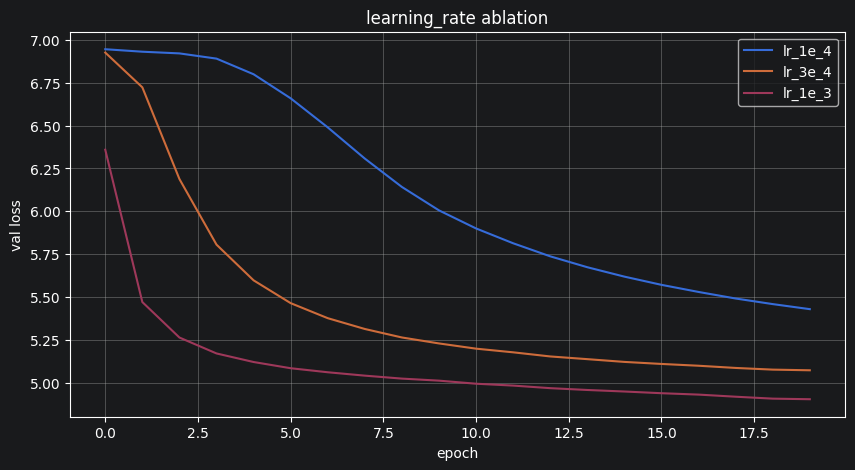

lr_1e_4 final val: 5.4297 best val: 5.4297 elapsed: 49.2
lr_3e_4 final val: 5.0733 best val: 5.0733 elapsed: 59.0
lr_1e_3 final val: 4.9046 best val: 4.9046 elapsed: 50.2


In [39]:
# ABLATION_LEARNING_RATE
learning_rate_results = run_ablation(
    "learning_rate",
    [
        ("lr_1e_4", {"learning_rate": 1e-4}),
        ("lr_3e_4", {"learning_rate": 3e-4}),
        ("lr_1e_3", {"learning_rate": 1e-3}),
    ],
    epochs=20,
)


이건 27번째 코드 셀이에요


optimizer_weight_decay adamw_wd_0
optimizer_weight_decay/adamw_wd_0 epoch 001 train 7.0561 val 6.9256
optimizer_weight_decay/adamw_wd_0 epoch 002 train 6.8731 val 6.7230
optimizer_weight_decay/adamw_wd_0 epoch 003 train 6.5174 val 6.1885
optimizer_weight_decay/adamw_wd_0 epoch 004 train 6.0586 val 5.8060
optimizer_weight_decay/adamw_wd_0 epoch 005 train 5.7780 val 5.5978
optimizer_weight_decay/adamw_wd_0 epoch 006 train 5.5989 val 5.4648
optimizer_weight_decay/adamw_wd_0 epoch 007 train 5.4760 val 5.3771
optimizer_weight_decay/adamw_wd_0 epoch 008 train 5.3857 val 5.3141
optimizer_weight_decay/adamw_wd_0 epoch 009 train 5.3168 val 5.2646
optimizer_weight_decay/adamw_wd_0 epoch 010 train 5.2615 val 5.2299
optimizer_weight_decay/adamw_wd_0 epoch 011 train 5.2155 val 5.1994
optimizer_weight_decay/adamw_wd_0 epoch 012 train 5.1785 val 5.1781
optimizer_weight_decay/adamw_wd_0 epoch 013 train 5.1459 val 5.1540
optimizer_weight_decay/adamw_wd_0 epoch 014 train 5.1170 val 5.1383
optimizer_weig

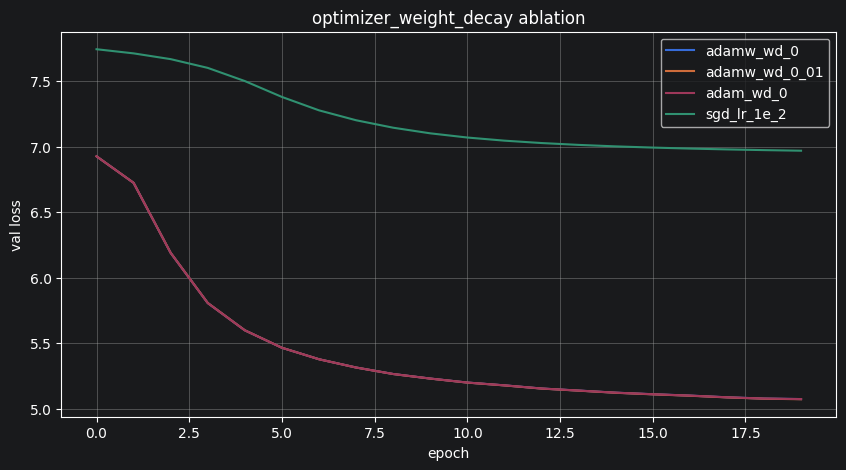

adamw_wd_0 final val: 5.0733 best val: 5.0733 elapsed: 51.7
adamw_wd_0_01 final val: 5.0721 best val: 5.0721 elapsed: 50.9
adam_wd_0 final val: 5.0733 best val: 5.0733 elapsed: 51.3
sgd_lr_1e_2 final val: 6.9682 best val: 6.9682 elapsed: 54.6


In [40]:
# ABLATION_OPTIMIZER_WEIGHT_DECAY
optimizer_weight_decay_results = run_ablation(
    "optimizer_weight_decay",
    [
        ("adamw_wd_0", {"optimizer": "adamw", "weight_decay": 0.0}),
        ("adamw_wd_0_01", {"optimizer": "adamw", "weight_decay": 0.01}),
        ("adam_wd_0", {"optimizer": "adam", "weight_decay": 0.0}),
        ("sgd_lr_1e_2", {"optimizer": "sgd", "learning_rate": 1e-2}),
    ],
    epochs=20,
)


이건 28번째 코드 셀이에요


context_length ctx_64
context_length/ctx_64 epoch 001 train 6.9993 val 6.8667
context_length/ctx_64 epoch 002 train 6.5588 val 6.0892
context_length/ctx_64 epoch 003 train 5.9225 val 5.6383
context_length/ctx_64 epoch 004 train 5.6029 val 5.4321
context_length/ctx_64 epoch 005 train 5.4284 val 5.3151
context_length/ctx_64 epoch 006 train 5.3178 val 5.2384
context_length/ctx_64 epoch 007 train 5.2390 val 5.1873
context_length/ctx_64 epoch 008 train 5.1790 val 5.1495
context_length/ctx_64 epoch 009 train 5.1322 val 5.1214
context_length/ctx_64 epoch 010 train 5.0933 val 5.0976
context_length/ctx_64 epoch 011 train 5.0599 val 5.0749
context_length/ctx_64 epoch 012 train 5.0300 val 5.0608
context_length/ctx_64 epoch 013 train 5.0033 val 5.0437
context_length/ctx_64 epoch 014 train 4.9794 val 5.0291
context_length/ctx_64 epoch 015 train 4.9569 val 5.0111
context_length/ctx_64 epoch 016 train 4.9364 val 4.9992
context_length/ctx_64 epoch 017 train 4.9159 val 4.9885
context_length/ctx_64 epoc

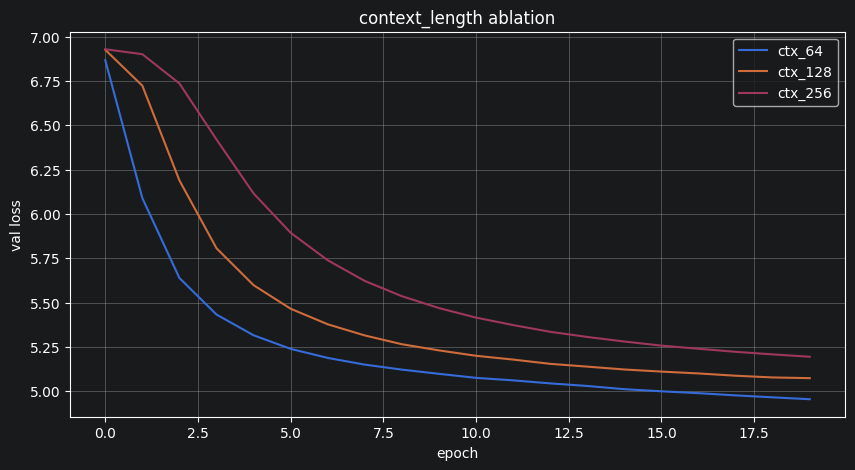

ctx_64 final val: 4.9544 best val: 4.9544 elapsed: 97.7
ctx_128 final val: 5.0733 best val: 5.0733 elapsed: 51.6
ctx_256 final val: 5.194 best val: 5.194 elapsed: 27.6


In [41]:
# ABLATION_CONTEXT_LENGTH
context_length_results = run_ablation(
    "context_length",
    [
        ("ctx_64", {"context_length": 64}),
        ("ctx_128", {"context_length": 128}),
        ("ctx_256", {"context_length": 256}),
    ],
    epochs=20,
)


이건 29번째 코드 셀이에요


vocab_size vocab_1000
vocab_size/vocab_1000 epoch 001 train 6.2572 val 5.8284
vocab_size/vocab_1000 epoch 002 train 5.4233 val 5.0141
vocab_size/vocab_1000 epoch 003 train 4.9416 val 4.7260
vocab_size/vocab_1000 epoch 004 train 4.7335 val 4.5928
vocab_size/vocab_1000 epoch 005 train 4.6215 val 4.5208
vocab_size/vocab_1000 epoch 006 train 4.5473 val 4.4647
vocab_size/vocab_1000 epoch 007 train 4.4927 val 4.4284
vocab_size/vocab_1000 epoch 008 train 4.4487 val 4.3891
vocab_size/vocab_1000 epoch 009 train 4.4120 val 4.3627
vocab_size/vocab_1000 epoch 010 train 4.3796 val 4.3332
vocab_size vocab_2000
vocab_size/vocab_2000 epoch 001 train 7.0561 val 6.9256
vocab_size/vocab_2000 epoch 002 train 6.8731 val 6.7230
vocab_size/vocab_2000 epoch 003 train 6.5174 val 6.1885
vocab_size/vocab_2000 epoch 004 train 6.0586 val 5.8060
vocab_size/vocab_2000 epoch 005 train 5.7780 val 5.5978
vocab_size/vocab_2000 epoch 006 train 5.5989 val 5.4648
vocab_size/vocab_2000 epoch 007 train 5.4760 val 5.3771
voca

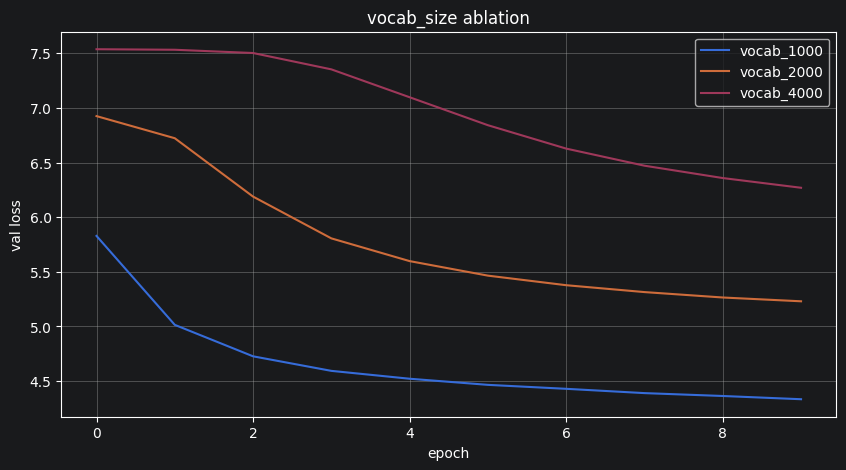

vocab_1000 final val: 4.3332 best val: 4.3332 elapsed: 35.2
vocab_2000 final val: 5.2299 best val: 5.2299 elapsed: 31.4
vocab_4000 final val: 6.2694 best val: 6.2694 elapsed: 23.4


In [42]:
# ABLATION_VOCAB_SIZE
vocab_size_results = run_ablation(
    "vocab_size",
    [
        ("vocab_1000", {"vocab_size": 1000}),
        ("vocab_2000", {"vocab_size": 2000}),
        ("vocab_4000", {"vocab_size": 4000}),
    ],
    epochs=10,
)


이건 30번째 코드 셀이에요


emb_dim emb_64
emb_dim/emb_64 epoch 001 train 7.1666 val 6.9367
emb_dim/emb_64 epoch 002 train 6.9369 val 6.9272
emb_dim/emb_64 epoch 003 train 6.9177 val 6.8896
emb_dim/emb_64 epoch 004 train 6.8448 val 6.7635
emb_dim/emb_64 epoch 005 train 6.6753 val 6.5101
emb_dim/emb_64 epoch 006 train 6.4266 val 6.2362
emb_dim/emb_64 epoch 007 train 6.2103 val 6.0366
emb_dim/emb_64 epoch 008 train 6.0463 val 5.8892
emb_dim/emb_64 epoch 009 train 5.9182 val 5.7739
emb_dim/emb_64 epoch 010 train 5.8157 val 5.6838
emb_dim/emb_64 epoch 011 train 5.7327 val 5.6113
emb_dim/emb_64 epoch 012 train 5.6639 val 5.5516
emb_dim/emb_64 epoch 013 train 5.6067 val 5.5019
emb_dim/emb_64 epoch 014 train 5.5572 val 5.4613
emb_dim/emb_64 epoch 015 train 5.5146 val 5.4251
emb_dim/emb_64 epoch 016 train 5.4761 val 5.3940
emb_dim/emb_64 epoch 017 train 5.4435 val 5.3669
emb_dim/emb_64 epoch 018 train 5.4134 val 5.3441
emb_dim/emb_64 epoch 019 train 5.3879 val 5.3224
emb_dim/emb_64 epoch 020 train 5.3644 val 5.3043
emb_d

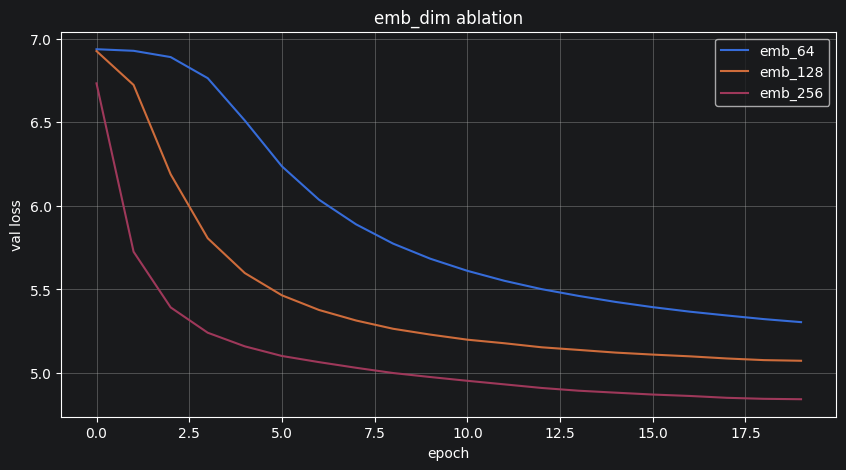

emb_64 final val: 5.3043 best val: 5.3043 elapsed: 50.8
emb_128 final val: 5.0733 best val: 5.0733 elapsed: 53.2
emb_256 final val: 4.8433 best val: 4.8433 elapsed: 55.0


In [43]:
# ABLATION_EMB_DIM
emb_dim_results = run_ablation(
    "emb_dim",
    [
        ("emb_64", {"emb_dim": 64}),
        ("emb_128", {"emb_dim": 128}),
        ("emb_256", {"emb_dim": 256}),
    ],
    epochs=20,
)


이건 31번째 코드 셀이에요


n_layers layers_1
n_layers/layers_1 epoch 001 train 7.1059 val 6.9131
n_layers/layers_1 epoch 002 train 6.8653 val 6.7484
n_layers/layers_1 epoch 003 train 6.5961 val 6.3487
n_layers/layers_1 epoch 004 train 6.2127 val 5.9558
n_layers/layers_1 epoch 005 train 5.9063 val 5.7118
n_layers/layers_1 epoch 006 train 5.7111 val 5.5645
n_layers/layers_1 epoch 007 train 5.5790 val 5.4695
n_layers/layers_1 epoch 008 train 5.4855 val 5.4007
n_layers/layers_1 epoch 009 train 5.4138 val 5.3491
n_layers/layers_1 epoch 010 train 5.3565 val 5.3101
n_layers/layers_1 epoch 011 train 5.3096 val 5.2774
n_layers/layers_1 epoch 012 train 5.2705 val 5.2511
n_layers/layers_1 epoch 013 train 5.2363 val 5.2262
n_layers/layers_1 epoch 014 train 5.2055 val 5.2080
n_layers/layers_1 epoch 015 train 5.1795 val 5.1894
n_layers/layers_1 epoch 016 train 5.1556 val 5.1746
n_layers/layers_1 epoch 017 train 5.1340 val 5.1628
n_layers/layers_1 epoch 018 train 5.1143 val 5.1500
n_layers/layers_1 epoch 019 train 5.0962 val 5

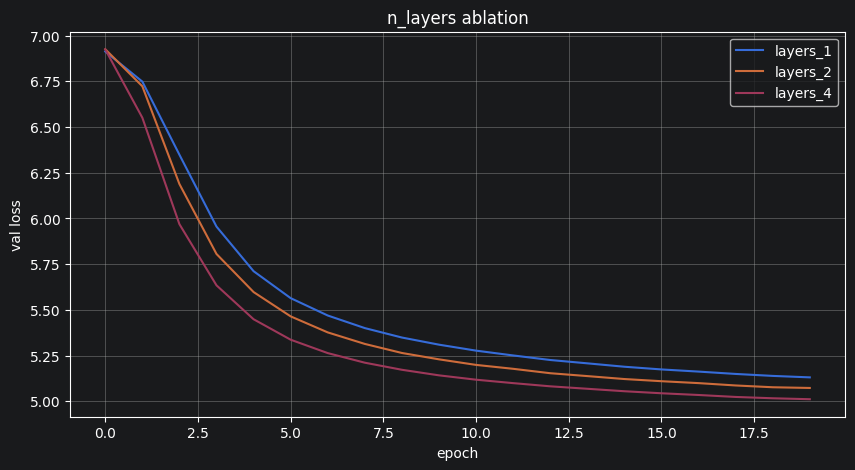

layers_1 final val: 5.1312 best val: 5.1312 elapsed: 34.1
layers_2 final val: 5.0733 best val: 5.0733 elapsed: 50.1
layers_4 final val: 5.0118 best val: 5.0118 elapsed: 87.8


In [44]:
# ABLATION_N_LAYERS
n_layers_results = run_ablation(
    "n_layers",
    [
        ("layers_1", {"n_layers": 1}),
        ("layers_2", {"n_layers": 2}),
        ("layers_4", {"n_layers": 4}),
    ],
    epochs=20,
)


이건 32번째 코드 셀이에요


n_heads heads_2
n_heads/heads_2 epoch 001 train 7.0562 val 6.9259
n_heads/heads_2 epoch 002 train 6.8734 val 6.7238
n_heads/heads_2 epoch 003 train 6.5173 val 6.1879
n_heads/heads_2 epoch 004 train 6.0601 val 5.8086
n_heads/heads_2 epoch 005 train 5.7794 val 5.5999
n_heads/heads_2 epoch 006 train 5.6013 val 5.4657
n_heads/heads_2 epoch 007 train 5.4776 val 5.3774
n_heads/heads_2 epoch 008 train 5.3865 val 5.3137
n_heads/heads_2 epoch 009 train 5.3178 val 5.2631
n_heads/heads_2 epoch 010 train 5.2618 val 5.2281
n_heads/heads_2 epoch 011 train 5.2178 val 5.1979
n_heads/heads_2 epoch 012 train 5.1794 val 5.1759
n_heads/heads_2 epoch 013 train 5.1465 val 5.1511
n_heads/heads_2 epoch 014 train 5.1185 val 5.1346
n_heads/heads_2 epoch 015 train 5.0929 val 5.1190
n_heads/heads_2 epoch 016 train 5.0712 val 5.1054
n_heads/heads_2 epoch 017 train 5.0500 val 5.0944
n_heads/heads_2 epoch 018 train 5.0301 val 5.0827
n_heads/heads_2 epoch 019 train 5.0133 val 5.0725
n_heads/heads_2 epoch 020 train 4.

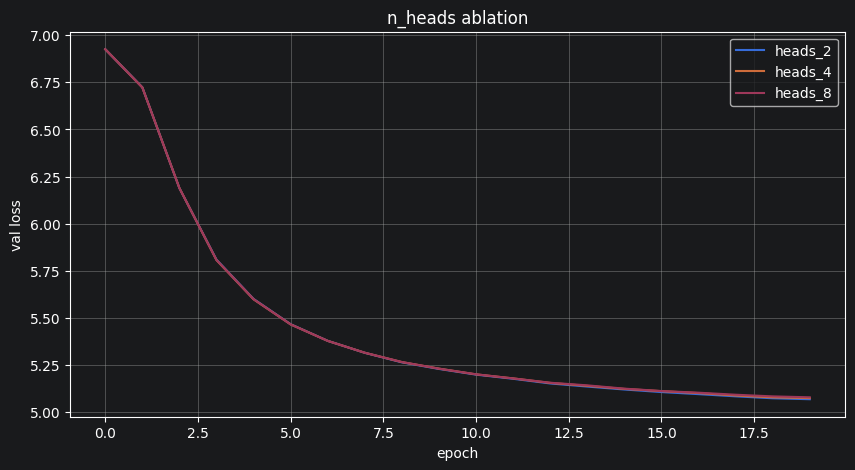

heads_2 final val: 5.0674 best val: 5.0674 elapsed: 53.4
heads_4 final val: 5.0733 best val: 5.0733 elapsed: 50.7
heads_8 final val: 5.0776 best val: 5.0776 elapsed: 51.5


In [45]:
# ABLATION_N_HEADS
n_heads_results = run_ablation(
    "n_heads",
    [
        ("heads_2", {"n_heads": 2}),
        ("heads_4", {"n_heads": 4}),
        ("heads_8", {"n_heads": 8}),
    ],
    epochs=20,
)


이건 33번째 코드 셀이에요


ffn_mult mult_2
ffn_mult/mult_2 epoch 001 train 7.0706 val 6.9278
ffn_mult/mult_2 epoch 002 train 6.9008 val 6.8147
ffn_mult/mult_2 epoch 003 train 6.6518 val 6.3893
ffn_mult/mult_2 epoch 004 train 6.2242 val 5.9567
ffn_mult/mult_2 epoch 005 train 5.9103 val 5.7230
ffn_mult/mult_2 epoch 006 train 5.7185 val 5.5786
ffn_mult/mult_2 epoch 007 train 5.5881 val 5.4813
ffn_mult/mult_2 epoch 008 train 5.4914 val 5.4083
ffn_mult/mult_2 epoch 009 train 5.4163 val 5.3517
ffn_mult/mult_2 epoch 010 train 5.3561 val 5.3083
ffn_mult/mult_2 epoch 011 train 5.3057 val 5.2725
ffn_mult/mult_2 epoch 012 train 5.2648 val 5.2463
ffn_mult/mult_2 epoch 013 train 5.2281 val 5.2185
ffn_mult/mult_2 epoch 014 train 5.1973 val 5.1991
ffn_mult/mult_2 epoch 015 train 5.1682 val 5.1792
ffn_mult/mult_2 epoch 016 train 5.1432 val 5.1634
ffn_mult/mult_2 epoch 017 train 5.1215 val 5.1506
ffn_mult/mult_2 epoch 018 train 5.1019 val 5.1374
ffn_mult/mult_2 epoch 019 train 5.0820 val 5.1256
ffn_mult/mult_2 epoch 020 train 5.

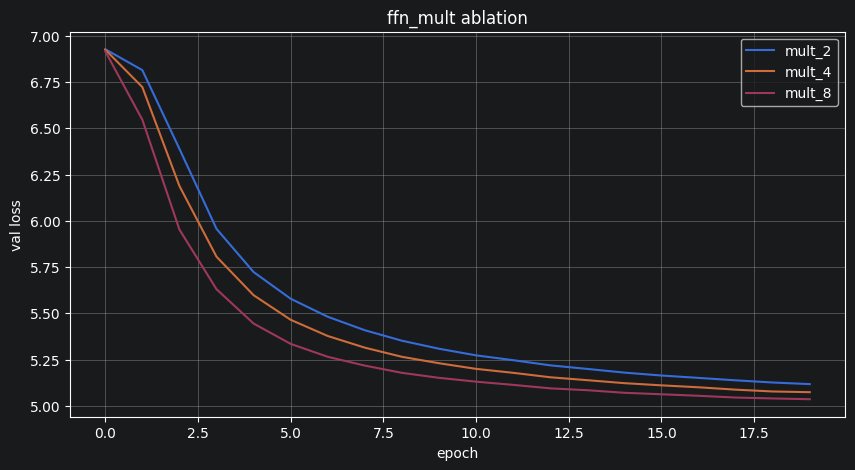

mult_2 final val: 5.117 best val: 5.117 elapsed: 51.2
mult_4 final val: 5.0733 best val: 5.0733 elapsed: 52.6
mult_8 final val: 5.0353 best val: 5.0353 elapsed: 52.8


In [46]:
# ABLATION_FFN_MULT
ffn_mult_results = run_ablation(
    "ffn_mult",
    [
        ("mult_2", {"ffn_mult": 2}),
        ("mult_4", {"ffn_mult": 4}),
        ("mult_8", {"ffn_mult": 8}),
    ],
    epochs=20,
)


이건 34번째 코드 셀이에요


grad_clip no_clip
grad_clip/no_clip epoch 001 train 7.0561 val 6.9256
grad_clip/no_clip epoch 002 train 6.8731 val 6.7230
grad_clip/no_clip epoch 003 train 6.5174 val 6.1885
grad_clip/no_clip epoch 004 train 6.0586 val 5.8060
grad_clip/no_clip epoch 005 train 5.7780 val 5.5978
grad_clip/no_clip epoch 006 train 5.5989 val 5.4648
grad_clip/no_clip epoch 007 train 5.4760 val 5.3771
grad_clip/no_clip epoch 008 train 5.3857 val 5.3141
grad_clip/no_clip epoch 009 train 5.3168 val 5.2646
grad_clip/no_clip epoch 010 train 5.2615 val 5.2299
grad_clip/no_clip epoch 011 train 5.2155 val 5.1994
grad_clip/no_clip epoch 012 train 5.1785 val 5.1781
grad_clip/no_clip epoch 013 train 5.1459 val 5.1540
grad_clip/no_clip epoch 014 train 5.1170 val 5.1383
grad_clip/no_clip epoch 015 train 5.0919 val 5.1222
grad_clip/no_clip epoch 016 train 5.0686 val 5.1103
grad_clip/no_clip epoch 017 train 5.0488 val 5.0998
grad_clip/no_clip epoch 018 train 5.0306 val 5.0870
grad_clip/no_clip epoch 019 train 5.0122 val 5

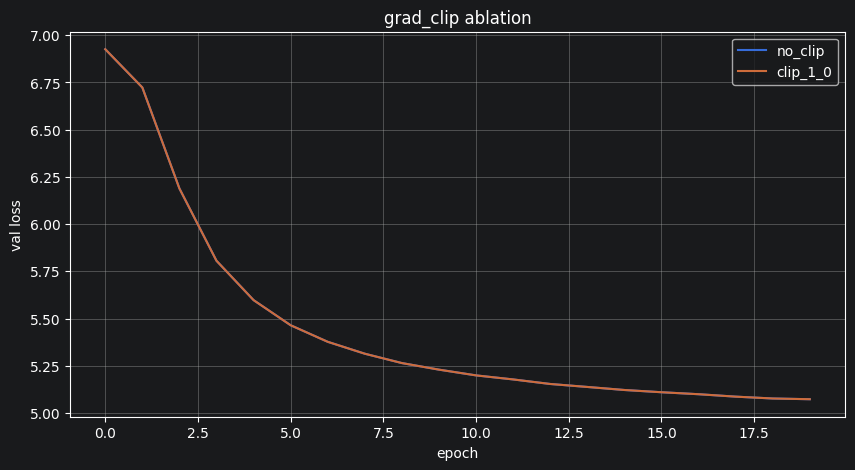

no_clip final val: 5.0733 best val: 5.0733 elapsed: 52.8
clip_1_0 final val: 5.0733 best val: 5.0733 elapsed: 51.5


In [47]:
# ABLATION_GRAD_CLIP
grad_clip_results = run_ablation(
    "grad_clip",
    [
        ("no_clip", {}),
        ("clip_1_0", {"grad_clip": 1.0}),
    ],
    epochs=20,
)


## 50 epoch ablation

Basic 설정을 기준으로 hyperparameter를 하나씩 바꿔 50 epoch씩 비교한다. 각 실험은 한 번에 하나의 값만 바꿔 영향 범위를 좁힌다.


이건 35번째 코드 셀이에요


In [1]:
# ABLATION50_COMMON_SETUP
# 50 epoch 실험에서 공통으로 쓰는 설정과 ablation 실행 함수를 모아둔 셀

from pathlib import Path
import json
import time
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel, FeedForward, GELU
from src.train import calc_loss_batch, calc_loss_loader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

TRAIN_TEXT = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
VAL_TEXT = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

ABLATION50_EPOCHS = 50
ABLATION50_SEED = 42
ABLATION50_DIR = Path("checkpoints")
ABLATION50_FIG_DIR = Path("figures")
ABLATION50_RESULT_DIR = ABLATION50_DIR / "ablation50"
ABLATION50_PLOT_DIR = ABLATION50_FIG_DIR / "ablation50"
ABLATION50_RESULT_DIR.mkdir(parents=True, exist_ok=True)
ABLATION50_PLOT_DIR.mkdir(parents=True, exist_ok=True)

TOKENIZER_CACHE = {}
IDS_CACHE = {}
DATASET50_CACHE = {}
ABLATION50_LAST_JSON = {}

BASE_CONFIG_50 = {
    "vocab_size": 2000,
    "context_length": 128,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}


def make_run_id50():
    return time.strftime("%Y%m%d_%H%M%S") + f"_{int((time.time() % 1) * 1000):03d}"


def latest_ablation50_json(category):
    paths = sorted(ABLATION50_RESULT_DIR.glob(f"ablation50_{category}_*.json"))
    if not paths:
        raise FileNotFoundError(f"No timestamped ablation50 result found for category={category!r}")
    return paths[-1]


def set_seed(seed=ABLATION50_SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_tokenizer50(vocab_size):
    if vocab_size in TOKENIZER_CACHE:
        return TOKENIZER_CACHE[vocab_size]

    path = Path(f"data/vocab_ablation_{vocab_size}.json")
    tokenizer = BPETokenizer(vocab_size=vocab_size)

    if path.exists():
        tokenizer.load(path)
        print(f"tokenizer loaded: {path}")
    else:
        print(f"train tokenizer: vocab_size={vocab_size}")
        tokenizer.train(TRAIN_TEXT)
        tokenizer.save(path)
        print(f"tokenizer saved: {path}")

    TOKENIZER_CACHE[vocab_size] = tokenizer
    return tokenizer


def get_ids50(vocab_size):
    if vocab_size in IDS_CACHE:
        return IDS_CACHE[vocab_size]

    tokenizer = get_tokenizer50(vocab_size)
    train_ids = tokenizer.encode(TRAIN_TEXT, add_bos_eos=False)
    val_ids = tokenizer.encode(VAL_TEXT, add_bos_eos=False)
    IDS_CACHE[vocab_size] = (train_ids, val_ids)
    print(f"encoded vocab={vocab_size}: train={len(train_ids)}, val={len(val_ids)}")
    return train_ids, val_ids


def make_activation50(name):
    if name == "gelu":
        return GELU()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)


def apply_model_overrides50(model, config, overrides):
    activation = overrides.get("activation", "gelu")
    ffn_mult = overrides.get("ffn_mult", 4)

    for block in model.blocks:
        block.ffn = FeedForward(
            config["emb_dim"],
            dropout=config["drop_rate"],
            mult=ffn_mult,
        ).to(DEVICE)
        block.ffn.net[1] = make_activation50(activation)


def get_dataset50(token_ids, context_length):
    cache_key = (id(token_ids), len(token_ids), context_length)
    if cache_key in DATASET50_CACHE:
        return DATASET50_CACHE[cache_key]

    token_tensor = torch.as_tensor(token_ids, dtype=torch.long)
    length = max(0, (len(token_ids) - context_length - 1) // context_length + 1)
    starts = torch.arange(length, dtype=torch.long) * context_length
    offsets = torch.arange(context_length, dtype=torch.long)
    indices = starts[:, None] + offsets[None, :]
    inputs = token_tensor[indices].contiguous()
    targets = token_tensor[indices + 1].contiguous()
    dataset = torch.utils.data.TensorDataset(inputs, targets)
    DATASET50_CACHE[cache_key] = dataset
    print(f"dataset cached: tokens={len(token_ids)}, context={context_length}, samples={length}")
    return dataset


def make_loader50(token_ids, context_length, batch_size, shuffle, seed):
    dataset = get_dataset50(token_ids, context_length)
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        drop_last=False,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )


def make_optimizer50(model, overrides):
    lr = overrides.get("learning_rate", 3e-4)
    weight_decay = overrides.get("weight_decay", 0.0)
    optimizer_name = overrides.get("optimizer", "adamw")

    if optimizer_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    raise ValueError(optimizer_name)


def run_one_variant50(category, label, overrides, epochs=ABLATION50_EPOCHS, seed=ABLATION50_SEED, base_overrides=None):
    set_seed(seed)

    variant_overrides = dict(overrides)
    active_overrides = dict(base_overrides or {})
    active_overrides.update(variant_overrides)

    config = dict(BASE_CONFIG_50)
    for key in ["vocab_size", "context_length", "emb_dim", "n_heads", "n_layers", "drop_rate", "qkv_bias"]:
        if key in active_overrides:
            config[key] = active_overrides[key]

    batch_size = active_overrides.get("batch_size", 32)
    vocab_size = config["vocab_size"]
    context_length = config["context_length"]

    train_ids, val_ids = get_ids50(vocab_size)
    train_loader = make_loader50(train_ids, context_length, batch_size, True, seed)
    val_loader = make_loader50(val_ids, context_length, batch_size, False, seed)

    model = GPTModel(config).to(DEVICE)
    apply_model_overrides50(model, config, active_overrides)
    optimizer = make_optimizer50(model, active_overrides)

    train_losses = []
    val_losses = []
    start = time.perf_counter()

    print(f"\n[{category}/{label}] start epochs={epochs} overrides={active_overrides}")
    print(f"train batches={len(train_loader)}, val batches={len(val_loader)}")

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
            loss.backward()

            if active_overrides.get("grad_clip") is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), active_overrides["grad_clip"])

            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = float(sum(epoch_losses) / len(epoch_losses))
        val_loss = calc_loss_loader(val_loader, model, DEVICE, num_batches=None)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"{category}/{label} epoch {epoch:03d}/{epochs} "
            f"train {train_loss:.4f} val {val_loss:.4f}"
        )

    elapsed = time.perf_counter() - start
    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "elapsed": elapsed,
        "overrides": active_overrides,
        "base_overrides": dict(base_overrides or {}),
        "variant_overrides": variant_overrides,
        "config": config,
        "batch_size": batch_size,
        "epochs": epochs,
        "seed": seed,
    }


def run_ablation50(category, variants, epochs=ABLATION50_EPOCHS, seed=ABLATION50_SEED, run_id=None, base_overrides=None):
    run_id = run_id or make_run_id50()
    results = {}
    if base_overrides:
        print(f"base overrides for {category}: {base_overrides}")
    for label, overrides in variants:
        results[label] = run_one_variant50(
            category,
            label,
            overrides,
            epochs=epochs,
            seed=seed,
            base_overrides=base_overrides,
        )

    out_path = ABLATION50_RESULT_DIR / f"ablation50_{category}_{run_id}.json"
    out_path.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")
    ABLATION50_LAST_JSON[category] = out_path
    print(f"saved: {out_path}")
    return results


def plot_ablation50(category, title=None, run_id=None, result_path=None):
    if result_path is not None:
        path = Path(result_path)
    elif run_id is not None:
        path = ABLATION50_RESULT_DIR / f"ablation50_{category}_{run_id}.json"
    elif category in ABLATION50_LAST_JSON:
        path = ABLATION50_LAST_JSON[category]
    else:
        path = latest_ablation50_json(category)

    data = json.loads(path.read_text(encoding="utf-8"))

    labels = list(data.keys())
    final_vals = [data[label]["val_loss"][-1] for label in labels]
    best_idx = min(range(len(final_vals)), key=lambda i: final_vals[i])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for label in labels:
        vals = data[label]["val_loss"]
        axes[0].plot(range(1, len(vals) + 1), vals, marker="o", markersize=3, label=label)

    axes[0].set_title(f"{title or category} validation loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("validation loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    colors = ["#4e79a7"] * len(labels)
    colors[best_idx] = "#59a14f"
    bars = axes[1].bar(labels, final_vals, color=colors)
    axes[1].set_title("final validation loss")
    axes[1].set_ylabel("validation loss")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].tick_params(axis="x", rotation=25)

    for bar, val in zip(bars, final_vals):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            val,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    fig.suptitle(f"50 epoch ablation: {title or category}")
    fig.tight_layout()

    run_id = path.stem.replace(f"ablation50_{category}_", "", 1)
    out_path = ABLATION50_PLOT_DIR / f"ablation50_{category}_{run_id}.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"saved: {out_path}")


device: cuda


### ABLATION50 - Activation


이건 36번째 코드 셀이에요


In [2]:
# ABLATION50_ACTIVATION_TRAIN
activation50_results = run_ablation50(
    "activation",
    [
        ("gelu", {"activation": "gelu"}),
        ("relu", {"activation": "relu"}),
        ("silu", {"activation": "silu"}),
        ("sigmoid", {"activation": "sigmoid"}),
    ],
    epochs=50,
)


train tokenizer: vocab_size=2000
tokenizer saved: data\vocab_ablation_2000.json
encoded vocab=2000: train=900849, val=78686

[activation/gelu] start epochs=50 overrides={'activation': 'gelu'}
train batches=220, val batches=20
activation/gelu epoch 001/50 train 7.0624 val 6.9265
activation/gelu epoch 002/50 train 6.8764 val 6.7384
activation/gelu epoch 003/50 train 6.5208 val 6.1781
activation/gelu epoch 004/50 train 6.0506 val 5.8000
activation/gelu epoch 005/50 train 5.7679 val 5.5875
activation/gelu epoch 006/50 train 5.5905 val 5.4578
activation/gelu epoch 007/50 train 5.4687 val 5.3722
activation/gelu epoch 008/50 train 5.3802 val 5.3076
activation/gelu epoch 009/50 train 5.3133 val 5.2599
activation/gelu epoch 010/50 train 5.2591 val 5.2227
activation/gelu epoch 011/50 train 5.2144 val 5.1977
activation/gelu epoch 012/50 train 5.1774 val 5.1711
activation/gelu epoch 013/50 train 5.1449 val 5.1507
activation/gelu epoch 014/50 train 5.1157 val 5.1339
activation/gelu epoch 015/50 tra

이건 37번째 코드 셀이에요


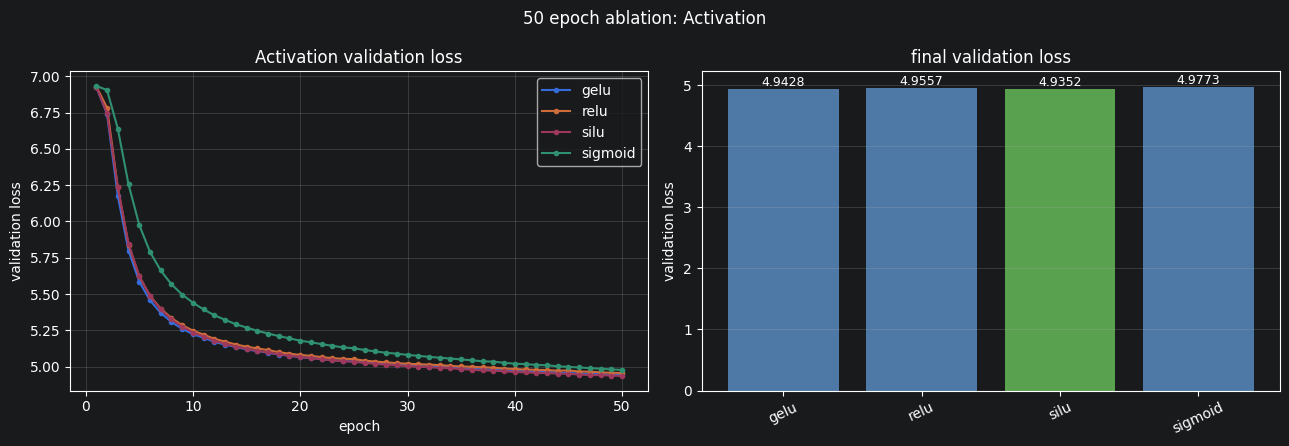

saved: figures\ablation50_activation.png


In [50]:
# ABLATION50_ACTIVATION_PLOT
plot_ablation50("activation", "Activation")


### ABLATION50 - Dropout


이건 38번째 코드 셀이에요


In [11]:
# ABLATION50_DROPOUT_TRAIN
dropout50_results = run_ablation50(
    "dropout",
    [
        ("drop_0_1", {"drop_rate": 0.1}),
        ("drop_0_14", {"drop_rate": 0.14}),
        ("drop_0_18", {"drop_rate": 0.18}),
    ],
    epochs=50,
)



[dropout/drop_0_1] start epochs=50 overrides={'drop_rate': 0.1}
train batches=220, val batches=20
dropout/drop_0_1 epoch 001/50 train 7.0624 val 6.9265
dropout/drop_0_1 epoch 002/50 train 6.8764 val 6.7384
dropout/drop_0_1 epoch 003/50 train 6.5208 val 6.1781
dropout/drop_0_1 epoch 004/50 train 6.0506 val 5.8000
dropout/drop_0_1 epoch 005/50 train 5.7679 val 5.5875
dropout/drop_0_1 epoch 006/50 train 5.5905 val 5.4578
dropout/drop_0_1 epoch 007/50 train 5.4687 val 5.3722
dropout/drop_0_1 epoch 008/50 train 5.3802 val 5.3076
dropout/drop_0_1 epoch 009/50 train 5.3133 val 5.2599
dropout/drop_0_1 epoch 010/50 train 5.2591 val 5.2227
dropout/drop_0_1 epoch 011/50 train 5.2144 val 5.1977
dropout/drop_0_1 epoch 012/50 train 5.1774 val 5.1711
dropout/drop_0_1 epoch 013/50 train 5.1449 val 5.1507
dropout/drop_0_1 epoch 014/50 train 5.1157 val 5.1339
dropout/drop_0_1 epoch 015/50 train 5.0904 val 5.1187
dropout/drop_0_1 epoch 016/50 train 5.0676 val 5.1066
dropout/drop_0_1 epoch 017/50 train 5

이건 39번째 코드 셀이에요


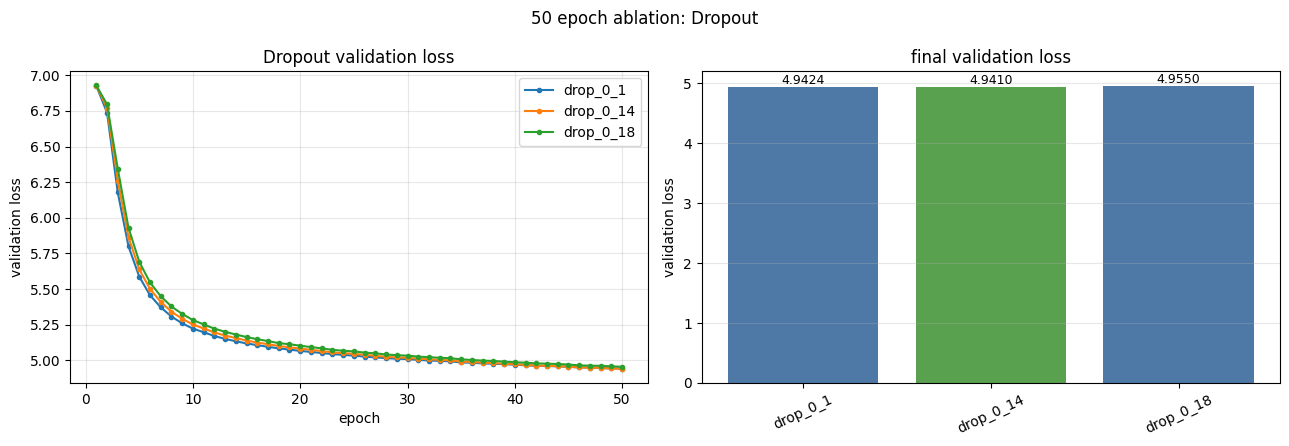

saved: figures\ablation50\ablation50_dropout_20260602_230007_406.png


In [12]:
# ABLATION50_DROPOUT_PLOT
plot_ablation50("dropout", "Dropout")


### ABLATION50 - Learning rate


이건 40번째 코드 셀이에요


In [ ]:
# ABLATION50_LEARNING_RATE_TRAIN
BEST_AFTER_DROPOUT_50 = {
    "drop_rate": 0.14,
}

learning_rate50_results = run_ablation50(
    "learning_rate",
    [
        ("lr_4.9e_3", {"learning_rate": 4.9e-3}),
        ("lr_5e_3", {"learning_rate": 5e-3}),
        ("lr_5.1e_3", {"learning_rate": 5.1e-3}),
    ],
    epochs=50,
    base_overrides=BEST_AFTER_DROPOUT_50,
)


base overrides for learning_rate: {'drop_rate': 0.14}

[learning_rate/lr_4.7e_3] start epochs=50 overrides={'drop_rate': 0.14, 'learning_rate': 0.0047}
train batches=220, val batches=20
learning_rate/lr_4.7e_3 epoch 001/50 train 6.2854 val 5.3685
learning_rate/lr_4.7e_3 epoch 002/50 train 5.2852 val 5.1394
learning_rate/lr_4.7e_3 epoch 003/50 train 5.1070 val 5.0555
learning_rate/lr_4.7e_3 epoch 004/50 train 5.0224 val 5.0127
learning_rate/lr_4.7e_3 epoch 005/50 train 4.9656 val 4.9842
learning_rate/lr_4.7e_3 epoch 006/50 train 4.9223 val 4.9590
learning_rate/lr_4.7e_3 epoch 007/50 train 4.8831 val 4.9342
learning_rate/lr_4.7e_3 epoch 008/50 train 4.8499 val 4.9042
learning_rate/lr_4.7e_3 epoch 009/50 train 4.8165 val 4.8777
learning_rate/lr_4.7e_3 epoch 010/50 train 4.7859 val 4.8581
learning_rate/lr_4.7e_3 epoch 011/50 train 4.7575 val 4.8355
learning_rate/lr_4.7e_3 epoch 012/50 train 4.7320 val 4.7982
learning_rate/lr_4.7e_3 epoch 013/50 train 4.7062 val 4.7867
learning_rate/lr_4.7e

이건 41번째 코드 셀이에요


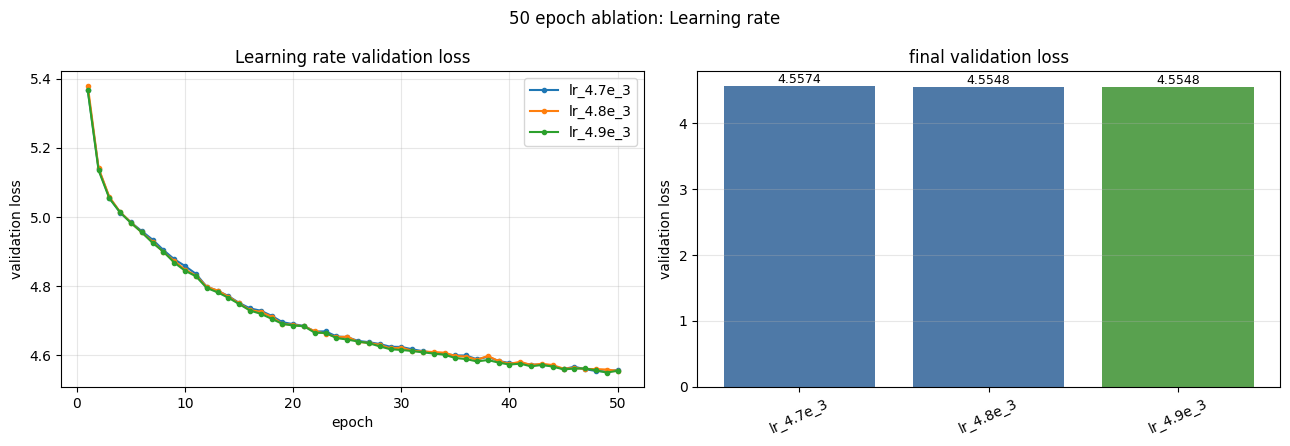

saved: figures\ablation50\ablation50_learning_rate_20260603_021017_021.png


In [49]:
# ABLATION50_LEARNING_RATE_PLOT
plot_ablation50("learning_rate", "Learning rate")


### ABLATION50 - Optimizer and weight decay


이건 42번째 코드 셀이에요


In [85]:
# ABLATION50_OPTIMIZER_WEIGHT_DECAY_TRAIN
BEST_AFTER_LEARNING_RATE_50 = {
    "drop_rate": 0.14,
    "learning_rate": 5e-3,
}

optimizer_weight_decay50_results = run_ablation50(
    "optimizer_weight_decay",
    [
        ("adamw_wd_0_06", {"optimizer": "adamw", "weight_decay": 0.06}),
        ("adam_wd_0_001", {"optimizer": "adam", "weight_decay": 0.001}),
        # ("sgd_lr_1e_2", {"optimizer": "sgd", "learning_rate": 1e-2}),
    ],
    epochs=50,
    base_overrides=BEST_AFTER_LEARNING_RATE_50,
)


base overrides for optimizer_weight_decay: {'drop_rate': 0.14, 'learning_rate': 0.005}

[optimizer_weight_decay/adamw_wd_0_06] start epochs=50 overrides={'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06}
train batches=220, val batches=20
optimizer_weight_decay/adamw_wd_0_06 epoch 001/50 train 6.2905 val 5.3627
optimizer_weight_decay/adamw_wd_0_06 epoch 002/50 train 5.2769 val 5.1340
optimizer_weight_decay/adamw_wd_0_06 epoch 003/50 train 5.0995 val 5.0511
optimizer_weight_decay/adamw_wd_0_06 epoch 004/50 train 5.0176 val 5.0114
optimizer_weight_decay/adamw_wd_0_06 epoch 005/50 train 4.9630 val 4.9778
optimizer_weight_decay/adamw_wd_0_06 epoch 006/50 train 4.9192 val 4.9429
optimizer_weight_decay/adamw_wd_0_06 epoch 007/50 train 4.8805 val 4.9131
optimizer_weight_decay/adamw_wd_0_06 epoch 008/50 train 4.8461 val 4.8839
optimizer_weight_decay/adamw_wd_0_06 epoch 009/50 train 4.8129 val 4.8493
optimizer_weight_decay/adamw_wd_0_06 epoch 010/50 train 4.7

이건 43번째 코드 셀이에요


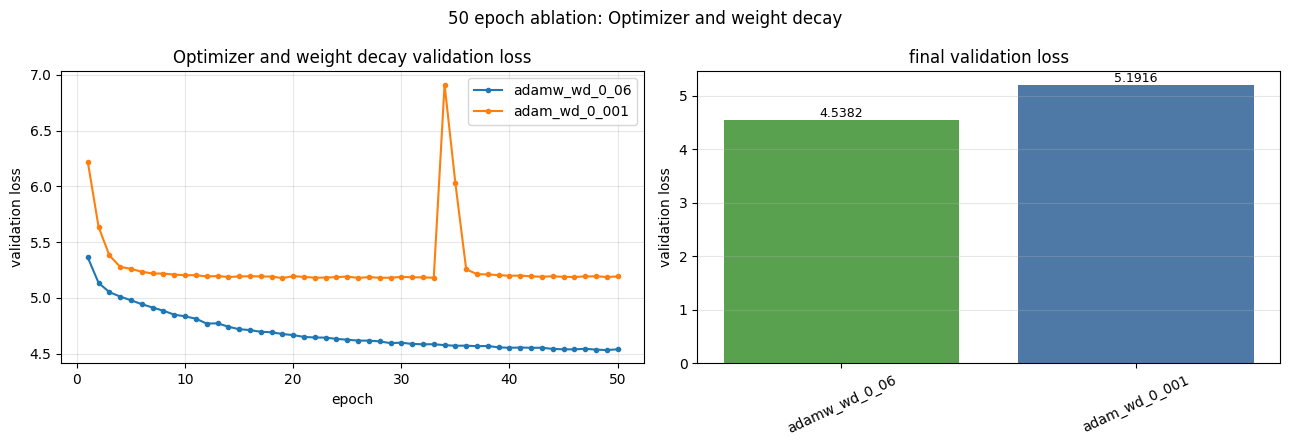

saved: figures\ablation50\ablation50_optimizer_weight_decay_20260603_151406_565.png


In [86]:
# ABLATION50_OPTIMIZER_WEIGHT_DECAY_PLOT
plot_ablation50("optimizer_weight_decay", "Optimizer and weight decay")


### ABLATION50 - Context length


이건 44번째 코드 셀이에요


In [113]:
# ABLATION50_CONTEXT_LENGTH_TRAIN
BEST_AFTER_LEARNING_RATE_50 = {
    "drop_rate": 0.14,
    "learning_rate": 5e-3,
    "optimizer": "adamw",
    "weight_decay": 0.06
}

context_length50_results = run_ablation50(
    "context_length",
    [
        ("ctx_64", {"context_length": 64}),
        ("ctx_80", {"context_length": 80}),
        ("ctx_96", {"context_length": 96}),
    ],
    epochs=50,
    base_overrides=BEST_AFTER_LEARNING_RATE_50,
)


base overrides for context_length: {'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06}

[context_length/ctx_64] start epochs=50 overrides={'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06, 'context_length': 64}
train batches=440, val batches=39
context_length/ctx_64 epoch 001/50 train 6.0157 val 5.2389
context_length/ctx_64 epoch 002/50 train 5.1895 val 5.0727
context_length/ctx_64 epoch 003/50 train 5.0545 val 4.9986
context_length/ctx_64 epoch 004/50 train 4.9760 val 4.9358
context_length/ctx_64 epoch 005/50 train 4.9127 val 4.8857
context_length/ctx_64 epoch 006/50 train 4.8626 val 4.8462
context_length/ctx_64 epoch 007/50 train 4.8218 val 4.8170
context_length/ctx_64 epoch 008/50 train 4.7878 val 4.7754
context_length/ctx_64 epoch 009/50 train 4.7576 val 4.7541
context_length/ctx_64 epoch 010/50 train 4.7333 val 4.7334
context_length/ctx_64 epoch 011/50 train 4.7101 val 4.7171
context_length/ctx_64 epoch 012/5

이건 45번째 코드 셀이에요


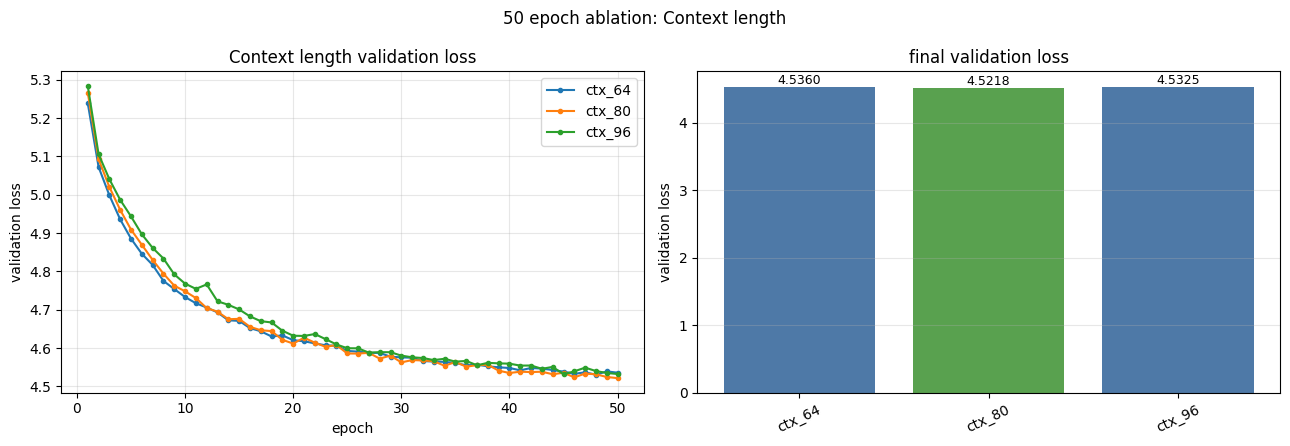

saved: figures\ablation50\ablation50_context_length_20260603_201721_327.png


In [114]:
# ABLATION50_CONTEXT_LENGTH_PLOT
plot_ablation50("context_length", "Context length")


### ABLATION50 - Vocab size


이건 46번째 코드 셀이에요


In [7]:
# ABLATION50_VOCAB_SIZE_TRAIN
BEST_AFTER_LEARNING_RATE_50 = {
    "drop_rate": 0.14,
    "learning_rate": 5e-3,
    "optimizer": "adamw",
    "weight_decay": 0.06,
    "context_length": 80
}

vocab_size50_results = run_ablation50(
    "vocab_size",
    [
        ("vocab_300", {"vocab_size": 300}),
        ("vocab_305", {"vocab_size": 305}),
        ("vocab_310", {"vocab_size": 310}),
    ],
    epochs=50,
    base_overrides=BEST_AFTER_LEARNING_RATE_50,
)


base overrides for vocab_size: {'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06, 'context_length': 80}

[vocab_size/vocab_300] start epochs=50 overrides={'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06, 'context_length': 80, 'vocab_size': 300}
train batches=937, val batches=82
vocab_size/vocab_300 epoch 001/50 train 2.5368 val 2.2265
vocab_size/vocab_300 epoch 002/50 train 2.2442 val 2.0998
vocab_size/vocab_300 epoch 003/50 train 2.1671 val 2.0462
vocab_size/vocab_300 epoch 004/50 train 2.1297 val 2.0265
vocab_size/vocab_300 epoch 005/50 train 2.1069 val 2.0033
vocab_size/vocab_300 epoch 006/50 train 2.0915 val 1.9932
vocab_size/vocab_300 epoch 007/50 train 2.0779 val 1.9803
vocab_size/vocab_300 epoch 008/50 train 2.0689 val 1.9660
vocab_size/vocab_300 epoch 009/50 train 2.0605 val 1.9626
vocab_size/vocab_300 epoch 010/50 train 2.0525 val 1.9564
vocab_size/vocab_300 epoch 011/50 train 2.0458 val 1.9521
vocab_si

이건 47번째 코드 셀이에요


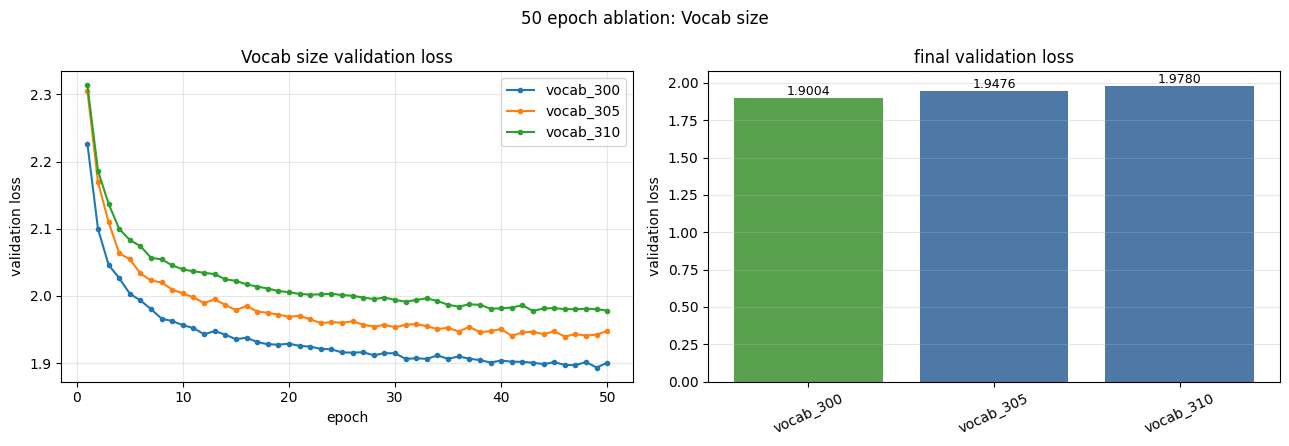

saved: figures\ablation50\ablation50_vocab_size_20260603_220128_985.png


In [8]:
# ABLATION50_VOCAB_SIZE_PLOT
plot_ablation50("vocab_size", "Vocab size")


### ABLATION50 - Embedding dimension


이건 48번째 코드 셀이에요


In [17]:
# ABLATION50_EMB_DIM_TRAIN
BEST_AFTER_LEARNING_RATE_50 = {
    "drop_rate": 0.14,
    "learning_rate": 5e-3,
    "optimizer": "adamw",
    "weight_decay": 0.06,
    "context_length": 80,
    "vocab_size": 300
}

emb_dim50_results = run_ablation50(
    "emb_dim",
    [
        ("emb_224", {"emb_dim": 312}),
        ("emb_320", {"emb_dim": 320}),
        ("emb_256", {"emb_dim": 328}),
    ],
    epochs=50,
    base_overrides=BEST_AFTER_LEARNING_RATE_50,
)


base overrides for emb_dim: {'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06, 'context_length': 80, 'vocab_size': 300}

[emb_dim/emb_224] start epochs=50 overrides={'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06, 'context_length': 80, 'vocab_size': 300, 'emb_dim': 312}
train batches=937, val batches=82
emb_dim/emb_224 epoch 001/50 train 2.4213 val 2.1218
emb_dim/emb_224 epoch 002/50 train 2.1345 val 2.0275
emb_dim/emb_224 epoch 003/50 train 2.0587 val 1.9655
emb_dim/emb_224 epoch 004/50 train 2.0148 val 1.9458
emb_dim/emb_224 epoch 005/50 train 1.9849 val 1.9202
emb_dim/emb_224 epoch 006/50 train 1.9626 val 1.8982
emb_dim/emb_224 epoch 007/50 train 1.9463 val 1.8858
emb_dim/emb_224 epoch 008/50 train 1.9338 val 1.8778
emb_dim/emb_224 epoch 009/50 train 1.9236 val 1.8667
emb_dim/emb_224 epoch 010/50 train 1.9148 val 1.8609
emb_dim/emb_224 epoch 011/50 train 1.9072 val 1.8554
emb_dim/emb_224 epoch 012/50 train 1

이건 49번째 코드 셀이에요


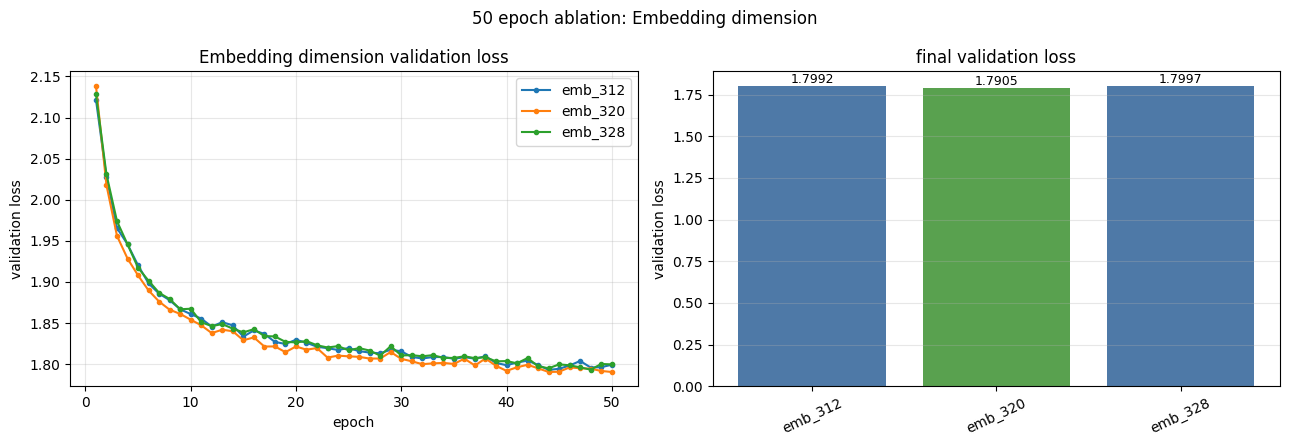

saved: figures\ablation50\ablation50_emb_dim_20260603_230558_068.png


In [19]:
# ABLATION50_EMB_DIM_PLOT
plot_ablation50("emb_dim", "Embedding dimension")


### ABLATION50 - Number of layers


이건 50번째 코드 셀이에요


In [25]:
# ABLATION50_N_LAYERS_TRAIN
BEST_AFTER_LEARNING_RATE_50 = {
    "drop_rate": 0.14,
    "learning_rate": 5e-3,
    "optimizer": "adamw",
    "weight_decay": 0.06,
    "context_length": 80,
    "vocab_size": 300,
    "emb_dim": 320
}

n_layers50_results = run_ablation50(
    "n_layers",
    [
        ("layers_11", {"n_layers": 11}),
        ("layers_12", {"n_layers": 12}),
    ],
    epochs=20,
    base_overrides=BEST_AFTER_LEARNING_RATE_50,
)


base overrides for n_layers: {'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06, 'context_length': 80, 'vocab_size': 300, 'emb_dim': 320}

[n_layers/layers_11] start epochs=20 overrides={'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06, 'context_length': 80, 'vocab_size': 300, 'emb_dim': 320, 'n_layers': 11}
train batches=937, val batches=82
n_layers/layers_11 epoch 001/20 train 2.6398 val 2.2823
n_layers/layers_11 epoch 002/20 train 2.2417 val 2.1087
n_layers/layers_11 epoch 003/20 train 2.1195 val 2.0179
n_layers/layers_11 epoch 004/20 train 2.0462 val 1.9519
n_layers/layers_11 epoch 005/20 train 1.9779 val 1.9007
n_layers/layers_11 epoch 006/20 train 1.9232 val 1.8542
n_layers/layers_11 epoch 007/20 train 1.8809 val 1.8271
n_layers/layers_11 epoch 008/20 train 1.8493 val 1.8031
n_layers/layers_11 epoch 009/20 train 1.8235 val 1.7892
n_layers/layers_11 epoch 010/20 train 1.8023 val 1.7705
n_layers/layers_11 epoc

KeyboardInterrupt: 

이건 51번째 코드 셀이에요


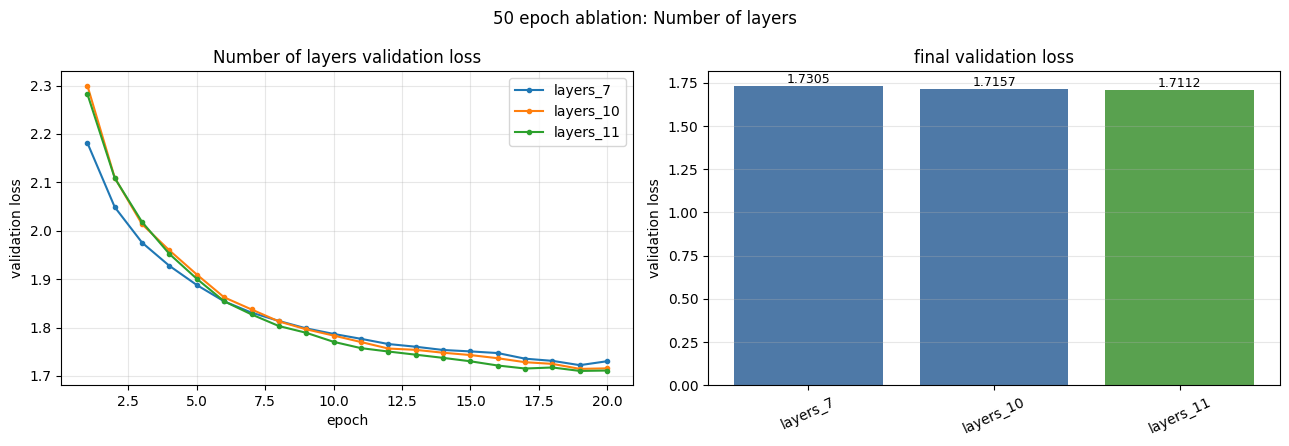

saved: figures\ablation50\ablation50_n_layers_20260604_003341_480.png


In [ ]:
# ABLATION50_N_LAYERS_PLOT
plot_ablation50("n_layers", "Number of layers")


### ABLATION50 - Number of heads


이건 52번째 코드 셀이에요


In [26]:
# ABLATION50_N_HEADS_TRAIN
BEST_AFTER_LEARNING_RATE_50 = {
    "drop_rate": 0.14,
    "learning_rate": 5e-3,
    "optimizer": "adamw",
    "weight_decay": 0.06,
    "context_length": 80,
    "vocab_size": 300,
    "emb_dim": 320,
    "n_layers": 13
}

n_heads50_results = run_ablation50(
    "n_heads",
    [
        ("heads_2", {"n_heads": 2}),
        ("heads_4", {"n_heads": 4}),
    ],
    epochs=10,
    base_overrides=BEST_AFTER_LEARNING_RATE_50,
)


base overrides for n_heads: {'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06, 'context_length': 80, 'vocab_size': 300, 'emb_dim': 320, 'n_layers': 13}

[n_heads/heads_2] start epochs=10 overrides={'drop_rate': 0.14, 'learning_rate': 0.005, 'optimizer': 'adamw', 'weight_decay': 0.06, 'context_length': 80, 'vocab_size': 300, 'emb_dim': 320, 'n_layers': 13, 'n_heads': 2}
train batches=937, val batches=82
n_heads/heads_2 epoch 001/10 train 2.7344 val 2.4972
n_heads/heads_2 epoch 002/10 train 2.4397 val 2.3399
n_heads/heads_2 epoch 003/10 train 2.4195 val 2.2686
n_heads/heads_2 epoch 004/10 train 2.2854 val 2.2177
n_heads/heads_2 epoch 005/10 train 2.2345 val 2.1313
n_heads/heads_2 epoch 006/10 train 2.0915 val 1.9686
n_heads/heads_2 epoch 007/10 train 1.9689 val 1.8851
n_heads/heads_2 epoch 008/10 train 1.9033 val 1.8404
n_heads/heads_2 epoch 009/10 train 1.8605 val 1.8087
n_heads/heads_2 epoch 010/10 train 1.8306 val 1.7921

[n_heads/heads_4] start ep

이건 53번째 코드 셀이에요


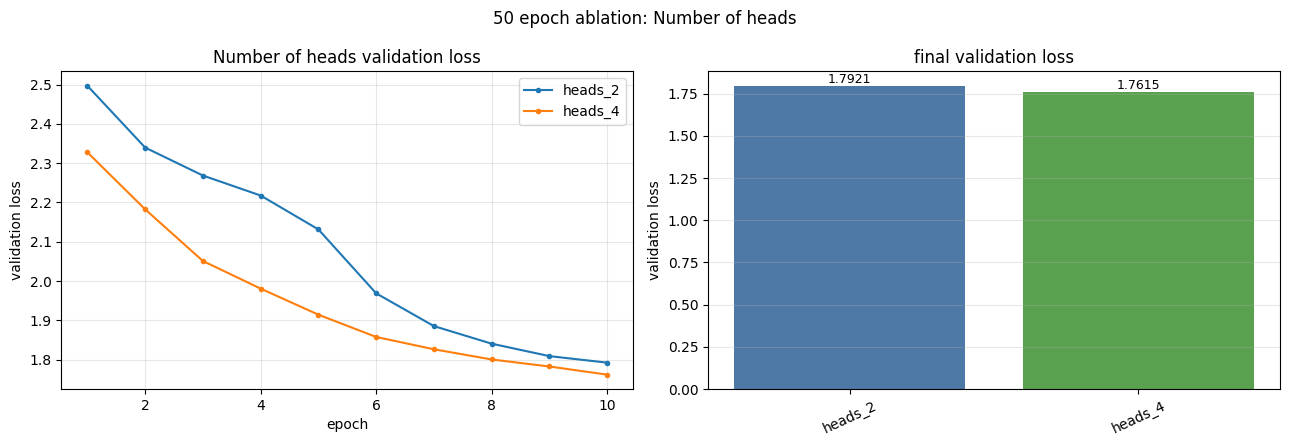

saved: figures\ablation50\ablation50_n_heads_20260604_022650_526.png


In [27]:
# ABLATION50_N_HEADS_PLOT
plot_ablation50("n_heads", "Number of heads")


### ABLATION50 - FFN expansion ratio


이건 54번째 코드 셀이에요


In [67]:
# ABLATION50_FFN_MULT_TRAIN
ffn_mult50_results = run_ablation50(
    "ffn_mult",
    [
        ("mult_2", {"ffn_mult": 2}),
        ("mult_4", {"ffn_mult": 4}),
        ("mult_8", {"ffn_mult": 8}),
    ],
    epochs=50,
)



[ffn_mult/mult_2] start epochs=50 overrides={'ffn_mult': 2}
train batches=220, val batches=20
ffn_mult/mult_2 epoch 001/50 train 7.0785 val 6.9282
ffn_mult/mult_2 epoch 002/50 train 6.9005 val 6.8149
ffn_mult/mult_2 epoch 003/50 train 6.6549 val 6.3841
ffn_mult/mult_2 epoch 004/50 train 6.2198 val 5.9576
ffn_mult/mult_2 epoch 005/50 train 5.9029 val 5.7195
ffn_mult/mult_2 epoch 006/50 train 5.7093 val 5.5732
ffn_mult/mult_2 epoch 007/50 train 5.5784 val 5.4759
ffn_mult/mult_2 epoch 008/50 train 5.4819 val 5.4042
ffn_mult/mult_2 epoch 009/50 train 5.4089 val 5.3497
ffn_mult/mult_2 epoch 010/50 train 5.3498 val 5.3059
ffn_mult/mult_2 epoch 011/50 train 5.3020 val 5.2736
ffn_mult/mult_2 epoch 012/50 train 5.2605 val 5.2432
ffn_mult/mult_2 epoch 013/50 train 5.2243 val 5.2189
ffn_mult/mult_2 epoch 014/50 train 5.1941 val 5.1974
ffn_mult/mult_2 epoch 015/50 train 5.1677 val 5.1804
ffn_mult/mult_2 epoch 016/50 train 5.1420 val 5.1634
ffn_mult/mult_2 epoch 017/50 train 5.1189 val 5.1501
ffn_

이건 55번째 코드 셀이에요


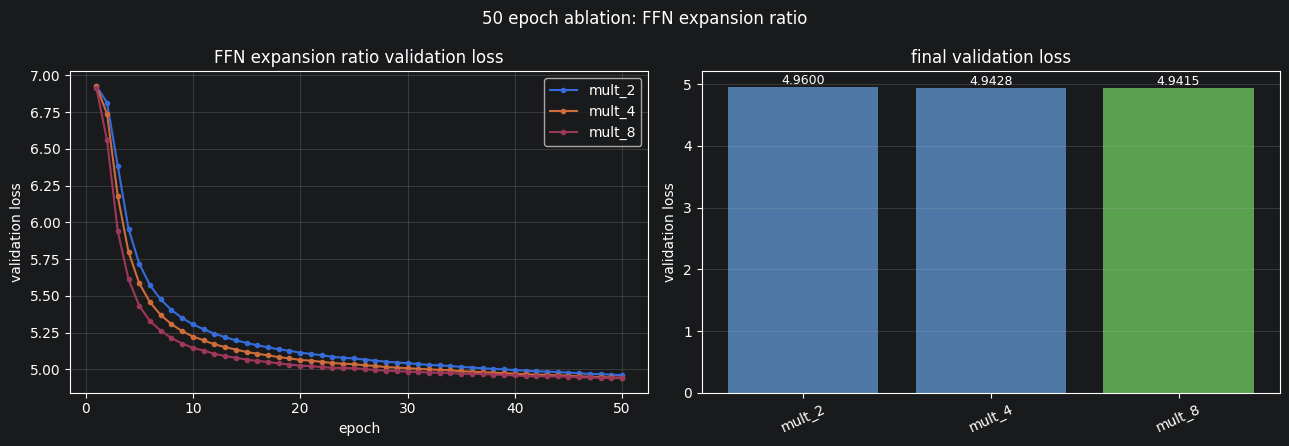

saved: figures\ablation50_ffn_mult.png


In [68]:
# ABLATION50_FFN_MULT_PLOT
plot_ablation50("ffn_mult", "FFN expansion ratio")


### ABLATION50 - Gradient clipping


이건 56번째 코드 셀이에요


In [69]:
# ABLATION50_GRAD_CLIP_TRAIN
grad_clip50_results = run_ablation50(
    "grad_clip",
    [
        ("no_clip", {}),
        ("clip_1_0", {"grad_clip": 1.0}),
    ],
    epochs=50,
)



[grad_clip/no_clip] start epochs=50 overrides={}
train batches=220, val batches=20
grad_clip/no_clip epoch 001/50 train 7.0622 val 6.9266
grad_clip/no_clip epoch 002/50 train 6.8764 val 6.7386
grad_clip/no_clip epoch 003/50 train 6.5212 val 6.1774
grad_clip/no_clip epoch 004/50 train 6.0501 val 5.7988
grad_clip/no_clip epoch 005/50 train 5.7660 val 5.5858
grad_clip/no_clip epoch 006/50 train 5.5889 val 5.4563
grad_clip/no_clip epoch 007/50 train 5.4683 val 5.3702
grad_clip/no_clip epoch 008/50 train 5.3792 val 5.3074
grad_clip/no_clip epoch 009/50 train 5.3115 val 5.2601
grad_clip/no_clip epoch 010/50 train 5.2573 val 5.2232
grad_clip/no_clip epoch 011/50 train 5.2140 val 5.1986
grad_clip/no_clip epoch 012/50 train 5.1765 val 5.1701
grad_clip/no_clip epoch 013/50 train 5.1441 val 5.1517
grad_clip/no_clip epoch 014/50 train 5.1156 val 5.1347
grad_clip/no_clip epoch 015/50 train 5.0911 val 5.1184
grad_clip/no_clip epoch 016/50 train 5.0684 val 5.1066
grad_clip/no_clip epoch 017/50 train

이건 57번째 코드 셀이에요


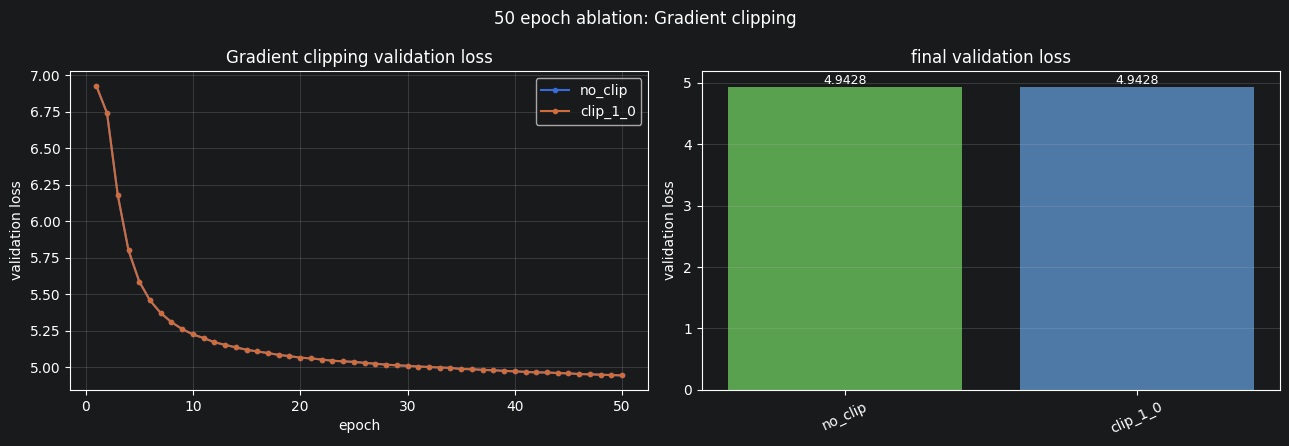

saved: figures\ablation50_grad_clip.png


In [70]:
# ABLATION50_GRAD_CLIP_PLOT
plot_ablation50("grad_clip", "Gradient clipping")


### ABLATION50 - Batch size


이건 58번째 코드 셀이에요


In [71]:
# ABLATION50_BATCH_SIZE_TRAIN
batch_size50_results = run_ablation50(
    "batch_size",
    [
        ("bs_16", {"batch_size": 16}),
        ("bs_32", {"batch_size": 32}),
        ("bs_64", {"batch_size": 64}),
    ],
    epochs=50,
)



[batch_size/bs_16] start epochs=50 overrides={'batch_size': 16}
train batches=440, val batches=39
batch_size/bs_16 epoch 001/50 train 7.0057 val 6.8828
batch_size/bs_16 epoch 002/50 train 6.6224 val 6.1771
batch_size/bs_16 epoch 003/50 train 5.9851 val 5.6921
batch_size/bs_16 epoch 004/50 train 5.6521 val 5.4753
batch_size/bs_16 epoch 005/50 train 5.4711 val 5.3566
batch_size/bs_16 epoch 006/50 train 5.3578 val 5.2820
batch_size/bs_16 epoch 007/50 train 5.2760 val 5.2340
batch_size/bs_16 epoch 008/50 train 5.2151 val 5.1925
batch_size/bs_16 epoch 009/50 train 5.1673 val 5.1617
batch_size/bs_16 epoch 010/50 train 5.1265 val 5.1381
batch_size/bs_16 epoch 011/50 train 5.0927 val 5.1228
batch_size/bs_16 epoch 012/50 train 5.0624 val 5.1007
batch_size/bs_16 epoch 013/50 train 5.0368 val 5.0864
batch_size/bs_16 epoch 014/50 train 5.0129 val 5.0735
batch_size/bs_16 epoch 015/50 train 4.9919 val 5.0631
batch_size/bs_16 epoch 016/50 train 4.9739 val 5.0497
batch_size/bs_16 epoch 017/50 train 4

이건 59번째 코드 셀이에요


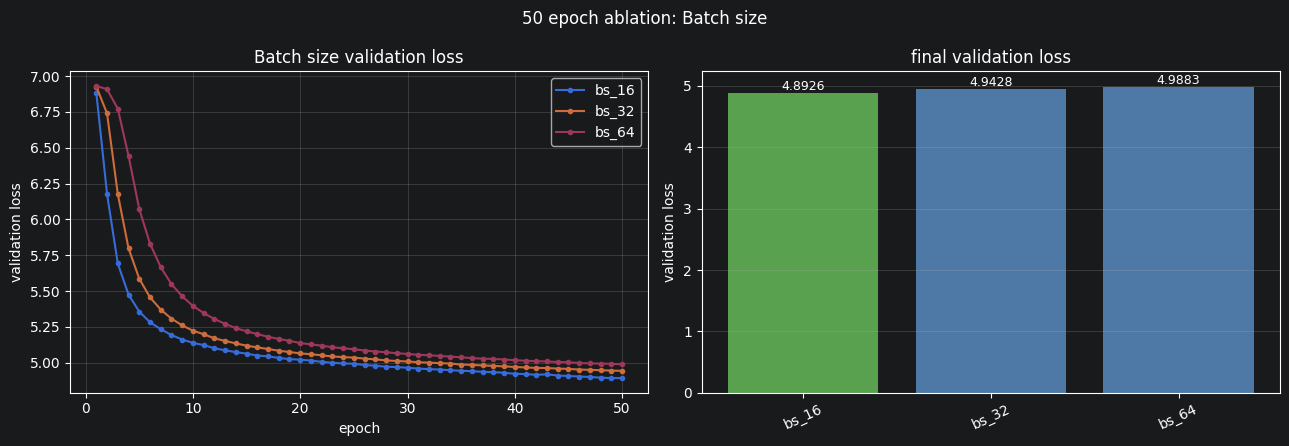

saved: figures\ablation50_batch_size.png


In [72]:
# ABLATION50_BATCH_SIZE_PLOT
plot_ablation50("batch_size", "Batch size")
